In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

Using cupy


Setting up the chain sequence

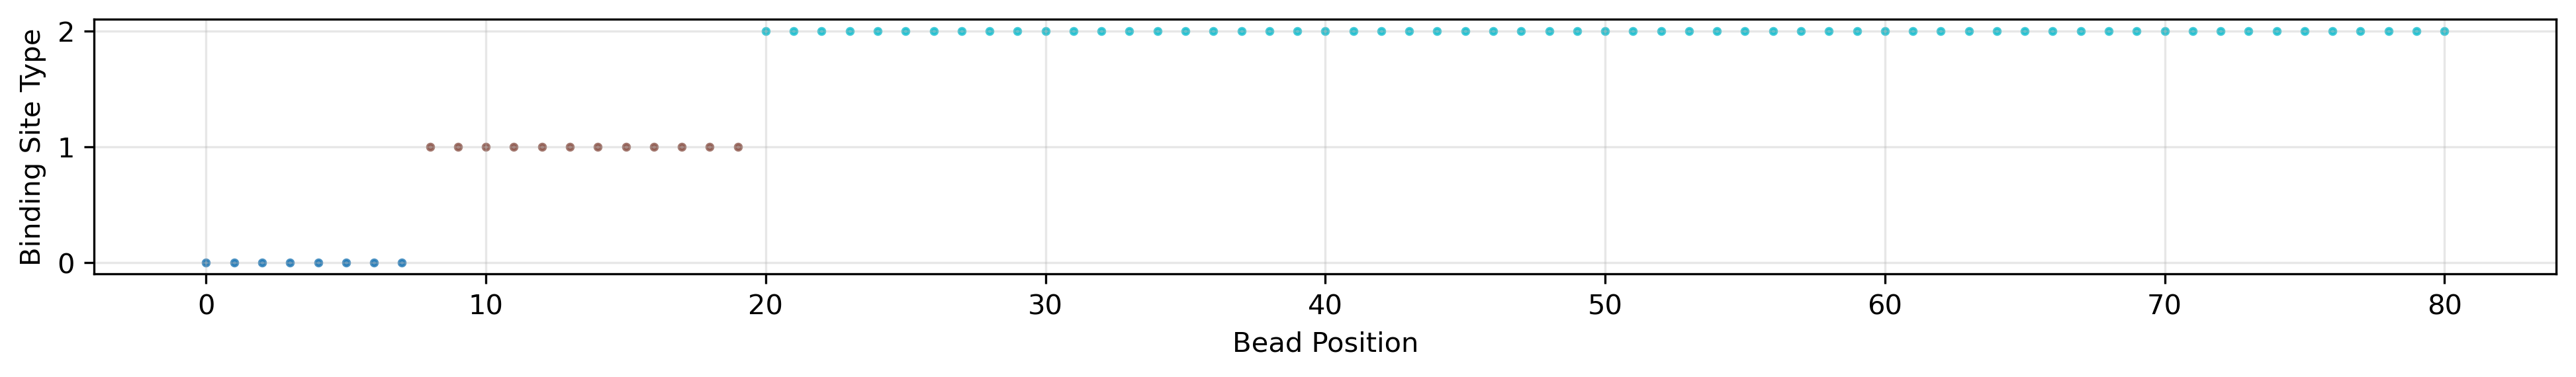

In [2]:
ns = 80

fa = 0.1
fb = 0.15
fc = 0.75

chain_interaction = np.zeros((3, ns+1))
chain_interaction[0, 0:int((ns+1)*fa)] += 1 # type A
chain_interaction[1, int((ns+1)*fa):int((ns+1)*fa+(ns+1)*fb)] += 1 # type B
chain_interaction[2, int((ns+1)*fa+(ns+1)*fb):] += 1 #type C

bead_sequence = onehot_to_color_labels(chain_interaction)
visualize_config(bead_sequence, chain_interaction.shape[0])

In [3]:
N = 20
Nseg = 1

chi_N_polymer = 15
chi_matrix = chi_N_polymer * np.ones((chain_interaction.shape[0], chain_interaction.shape[0]))
np.fill_diagonal(chi_matrix, 0)

phibar = 0.1

nx = ny = 128
initial_qsr = np.ones((nx, ny))
L = 100  #dimension of the box

parameter sweep for different chi_bs = chi_cs

In [4]:
from joblib import Parallel, delayed
from itertools import product

def single_run(Chi_cs):

    chi_bs = 10
    chi_cs = Chi_cs
    chi_polymer_s = np.array([0.5, chi_bs, chi_cs])

    polymer = Scft(
        N = N,
        Lx=L, Ly=L,
        phibar=phibar, # volume fraction of polymer
        l_p=np.sqrt(N),
        n_seg=1, # contour length of polymer normalized from 0-1
        nx=nx, ny=ny,
        ns=ns,
        iterations=10000,
        error_tol=1e-12,
        chain_interaction=chain_interaction,
        self_avoiding=0,
        initial_qsr=initial_qsr / np.mean(initial_qsr),
        mixing_rate=0.03,
        chi_polymer_block = chi_matrix,
        chi_polymer_s = chi_polymer_s,
        PB = 1,
        close_boundary=False,
    )
    wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, shift = 0)
    wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist, polymer_loop=False)

    corr_2d = pair_correlation_2D(to_numpy(qsr*qsr_d))

    return to_numpy(phi_blocks), to_numpy(qsr), diff, corr_2d, free_energy_hist

def parameter_sweep():

    chi_cs_list = np.array([18, 20, 22, 23, 23.5, 24, 24.1, 24.2,
                            24.3, 24.32, 24.32, 24.33, 24.34, 24.35, 24.36, 24.37, 24.38,24.39, 24.4,
                            24.5, 25, 25.5 ,26, 27, 28, 29, 30, 32.5, 35])

    #chi_cs_list = np.array([25, 27.5, 30, 33, 36, 40])
    results = Parallel(n_jobs = 3, backend="loky")(
        delayed(single_run)(Chi_cs)
        for Chi_cs in tqdm(chi_cs_list, total = len(chi_cs_list))
    )

    phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist = zip(*results)
    return chi_cs_list, phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist

In [5]:
chi_bs_list, phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist = parameter_sweep()

  0%|          | 0/29 [00:00<?, ?it/s]

In [6]:
np.savez("ABC_chi_cs_fine", chi_cs_list = chi_bs_list, phi_list = phi_list, qsr_list = qsr_list, diff_list = diff_list, corr_2d_list = corr_2d_list, free_energy_hist = free_energy_hist)

In [7]:
phi_list = np.array(phi_list)
print(phi_list.shape)

(29, 3, 128, 128)


0
18.0


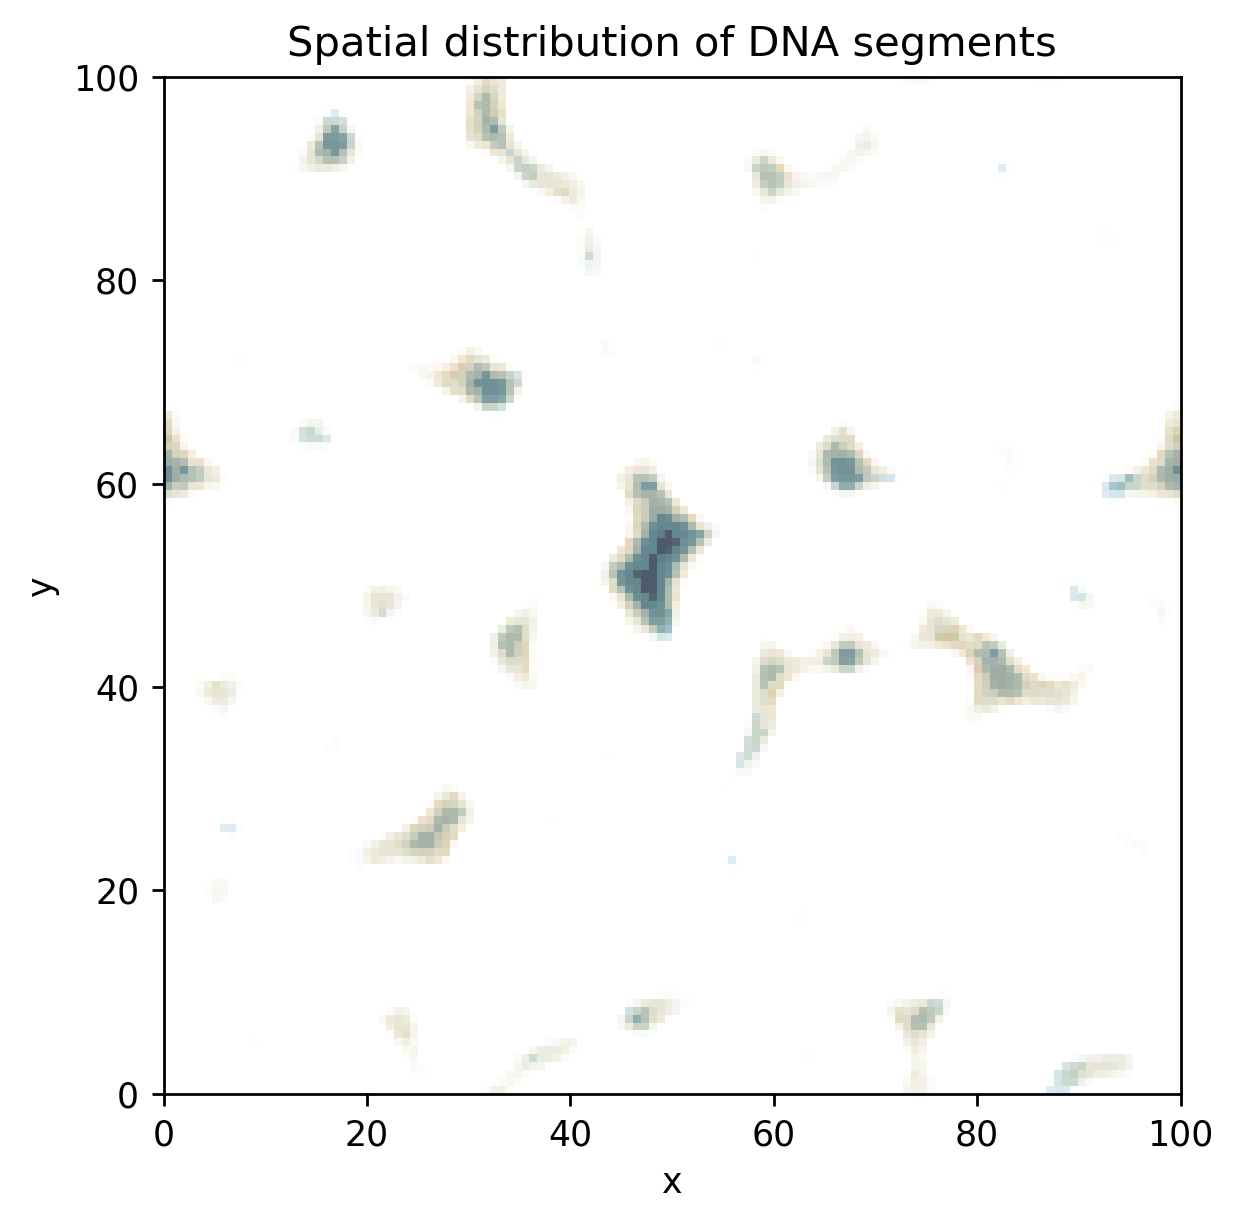

1
20.0


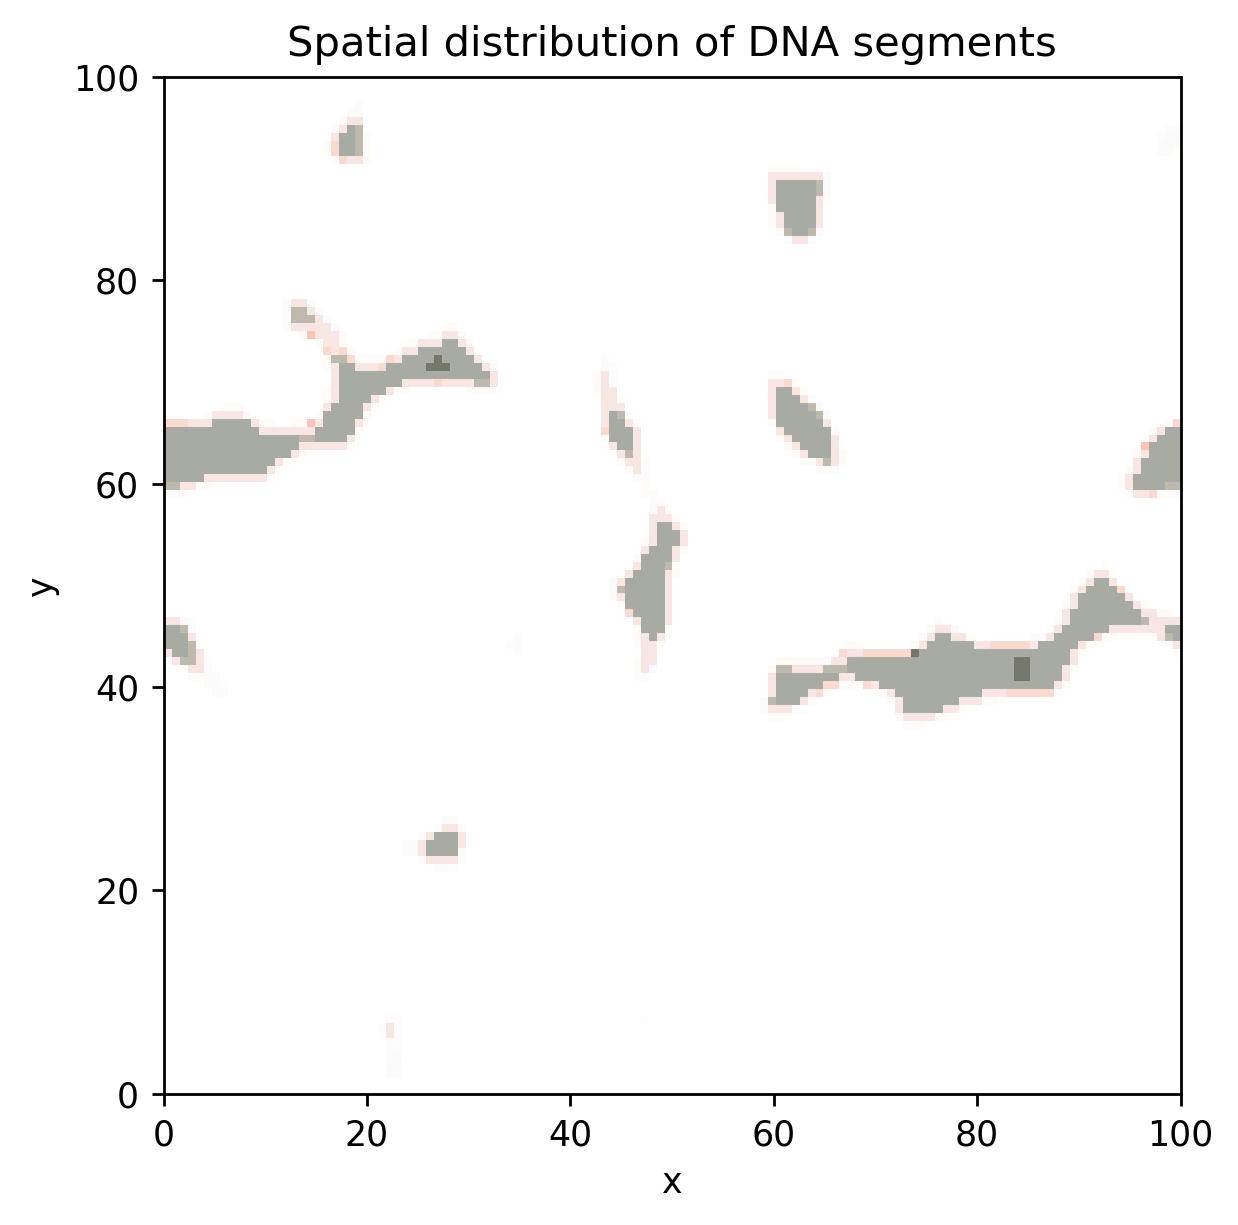

2
22.0


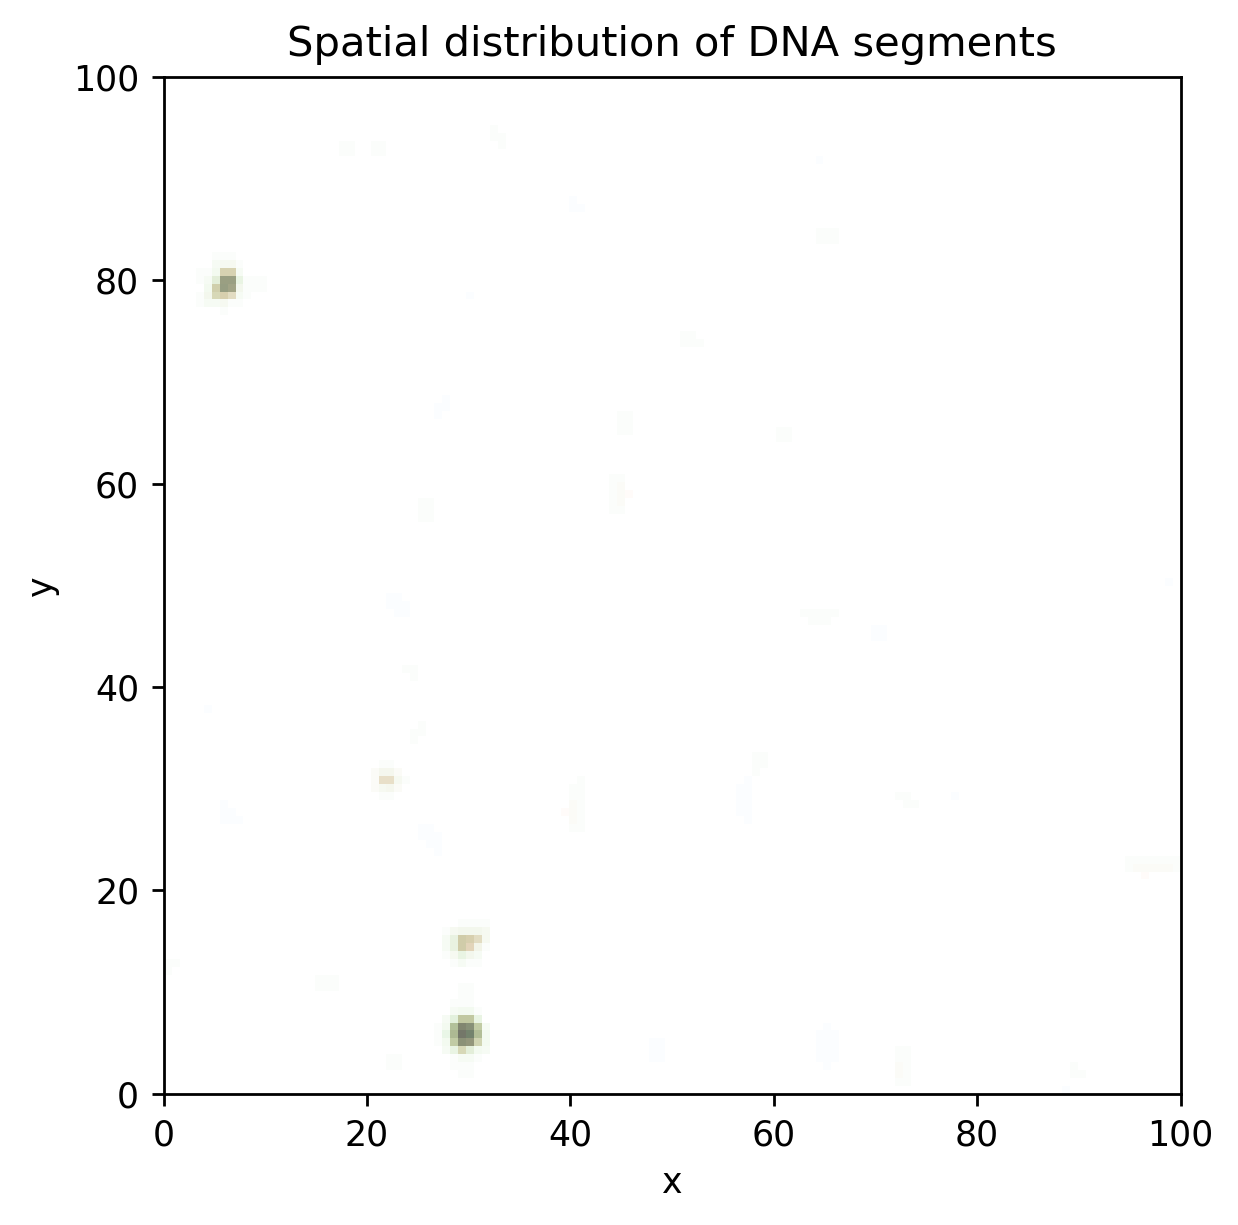

3
23.0


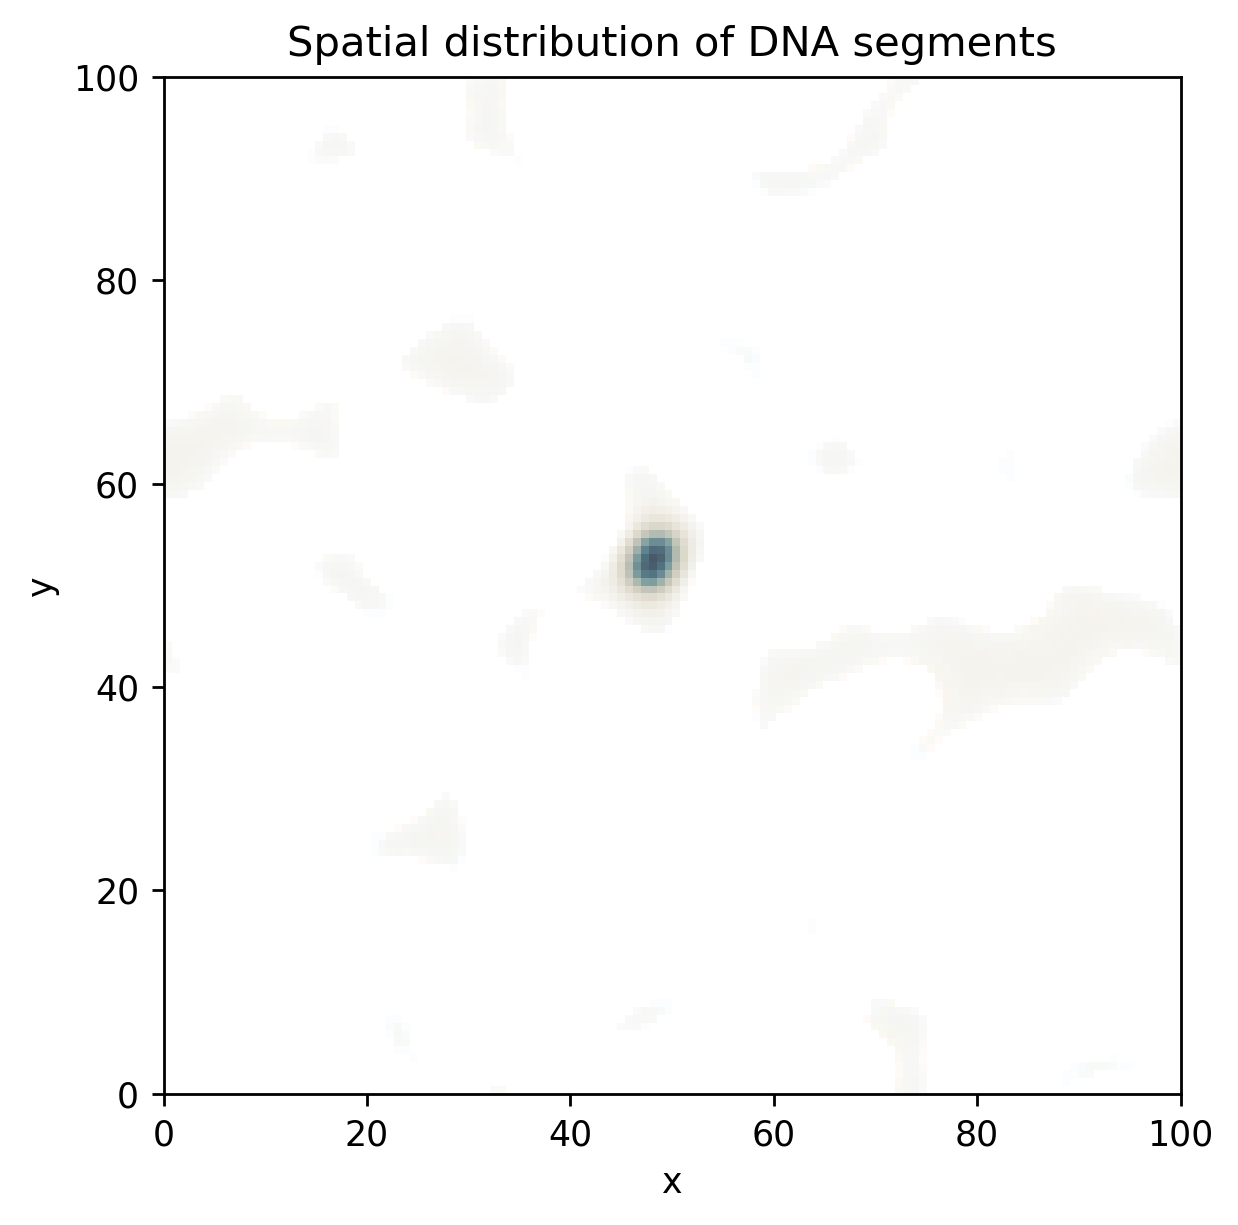

4
23.5


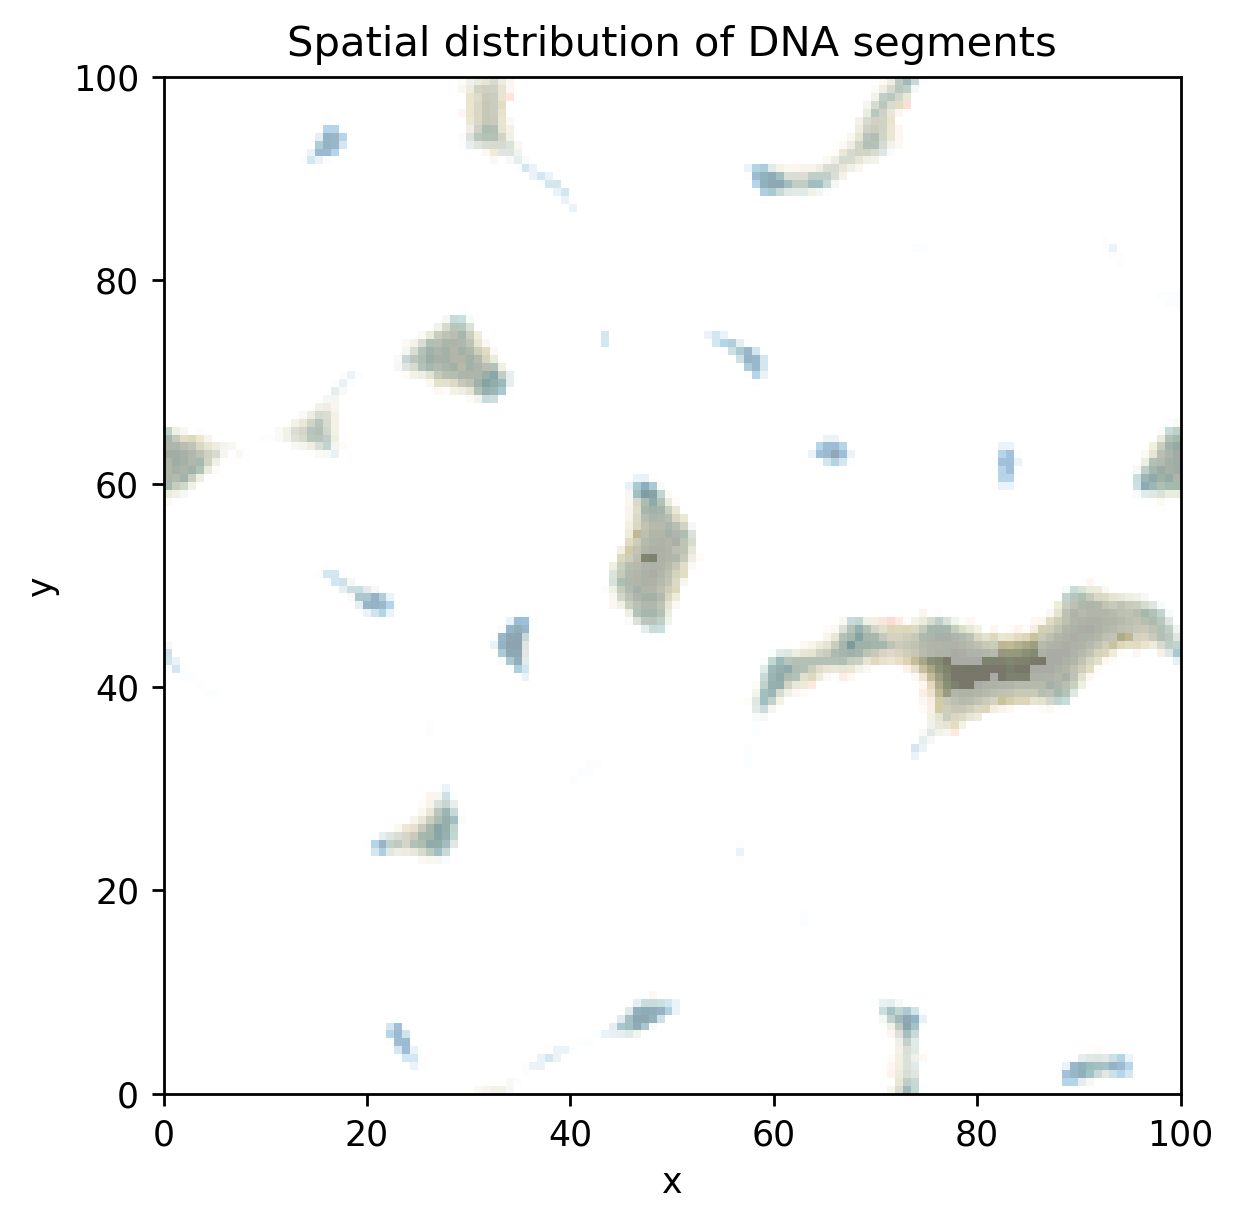

5
24.0


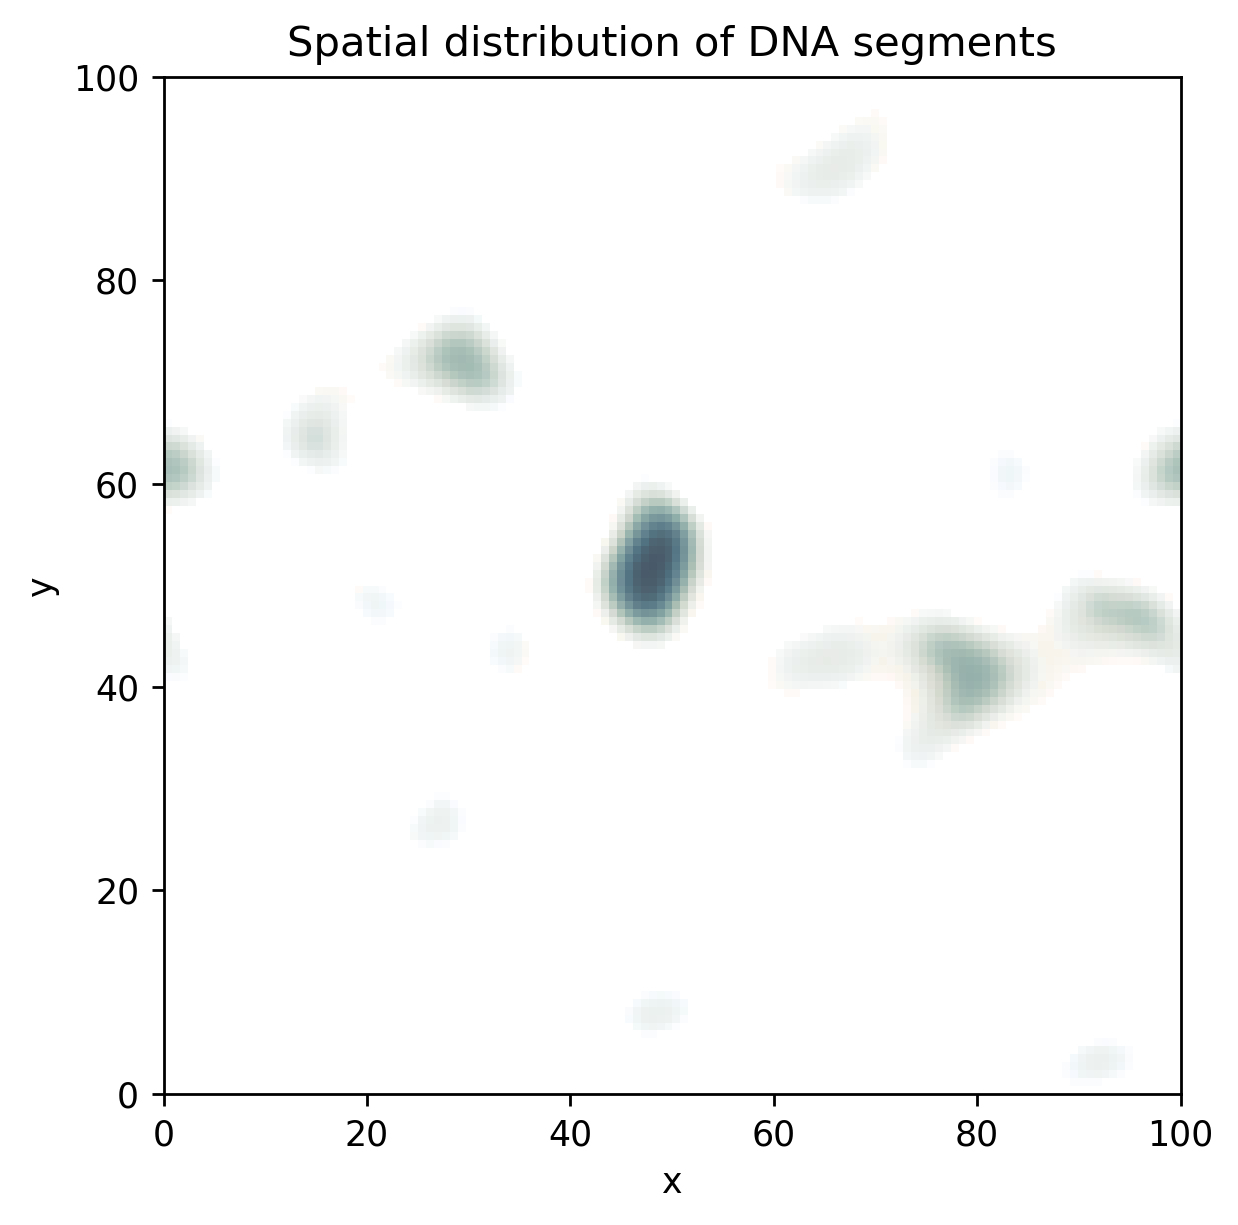

6
24.1


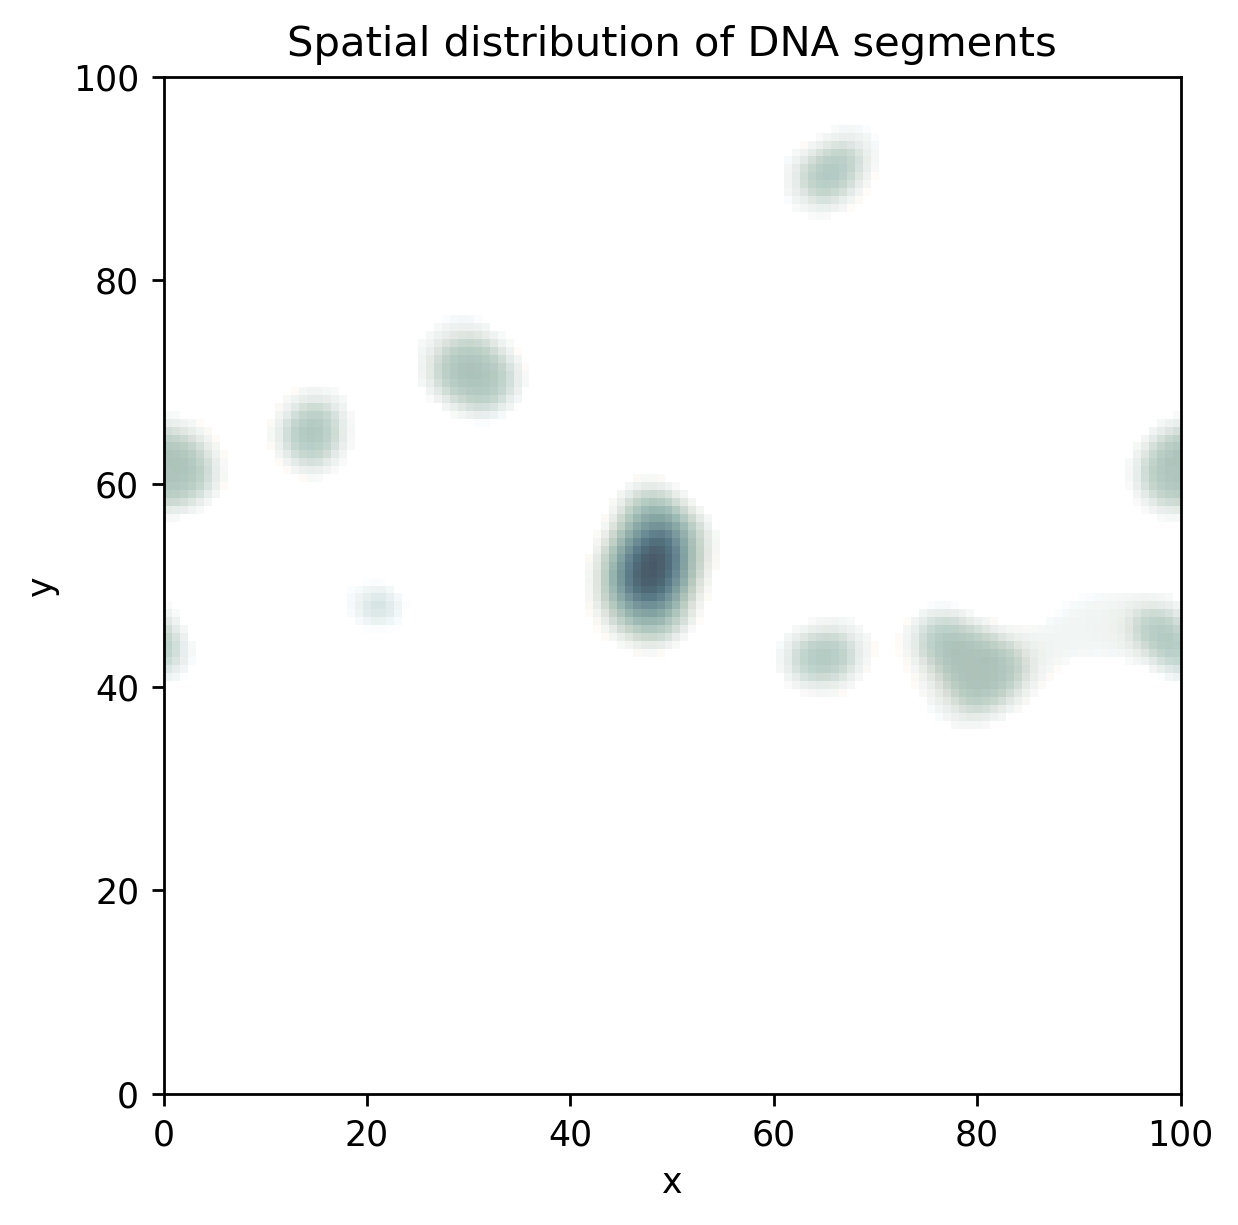

7
24.2


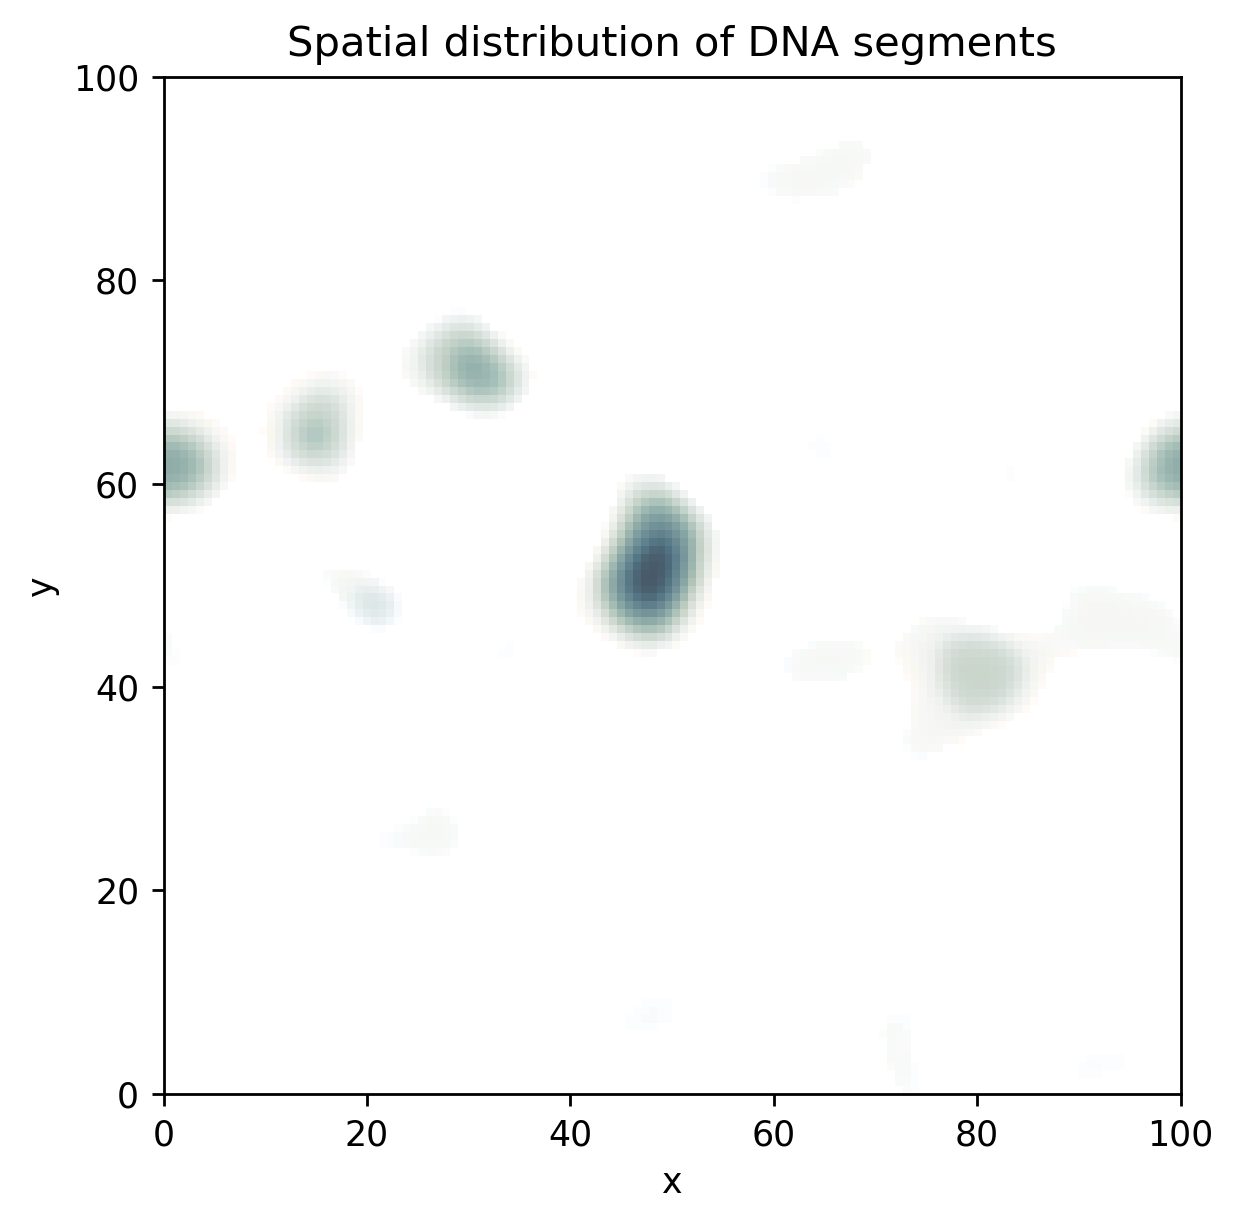

8
24.3


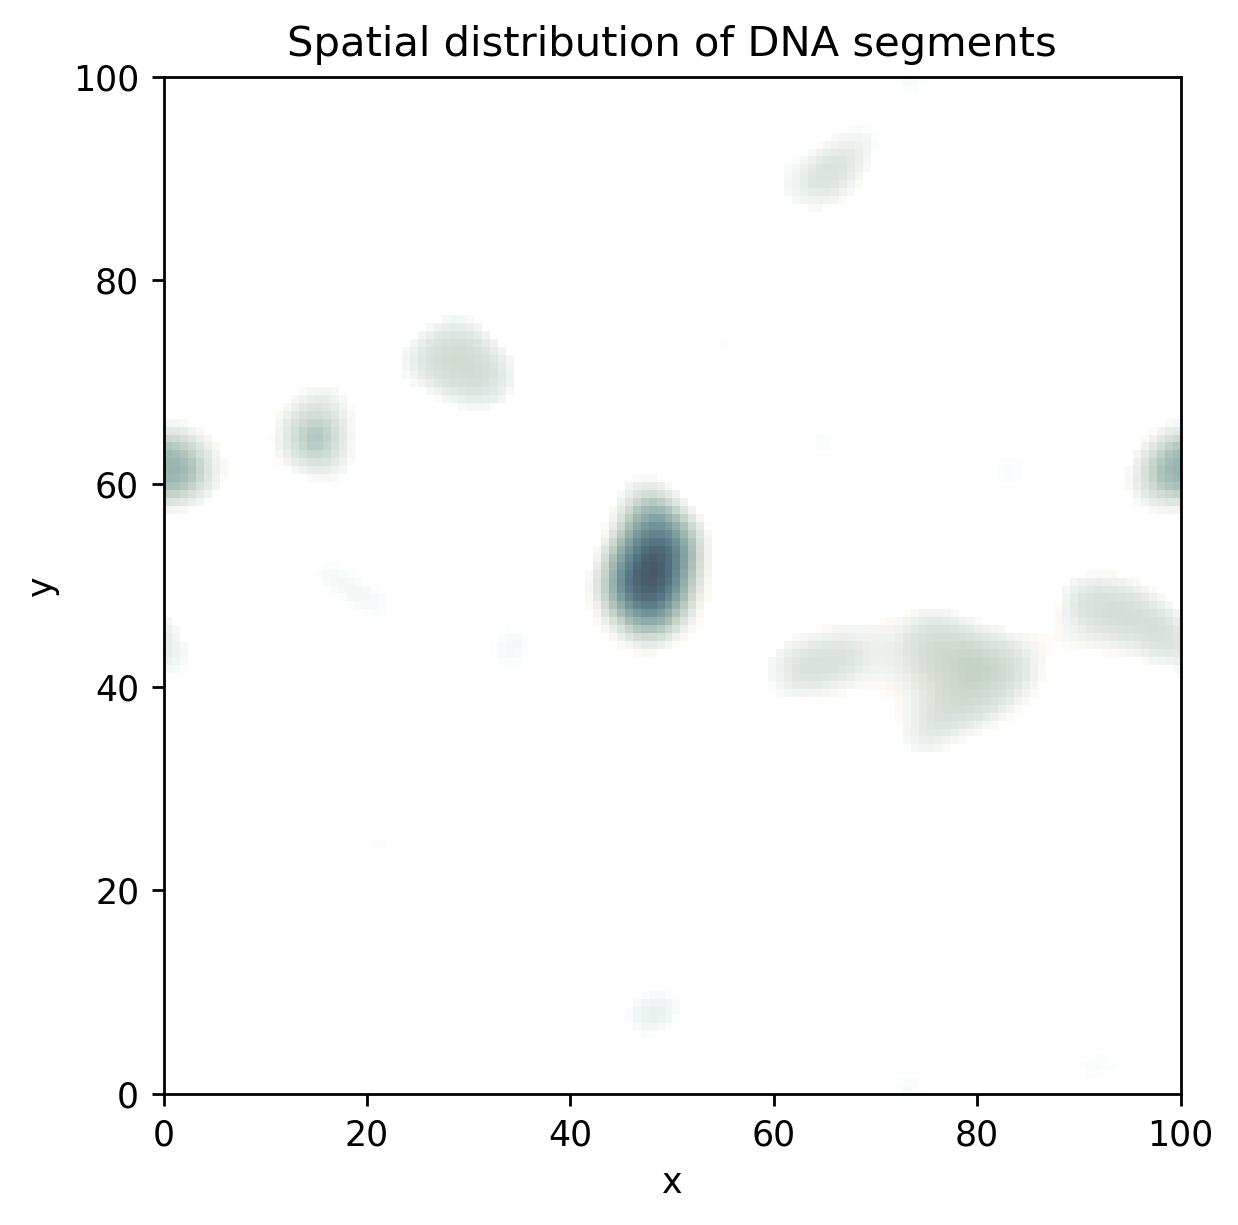

9
24.32


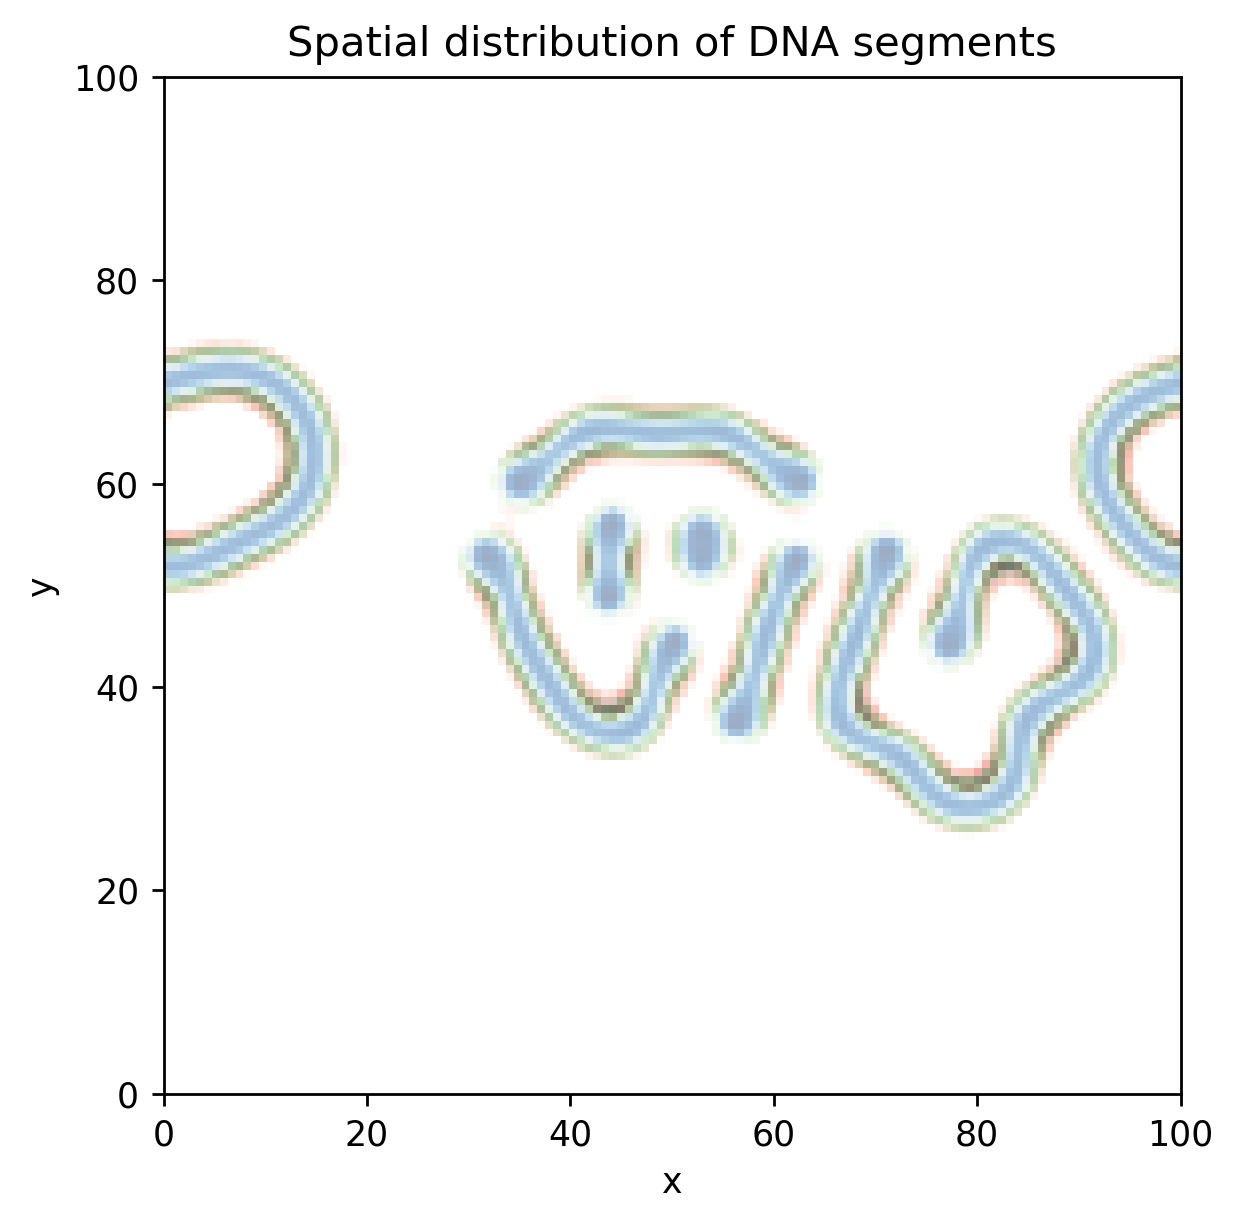

10
24.32


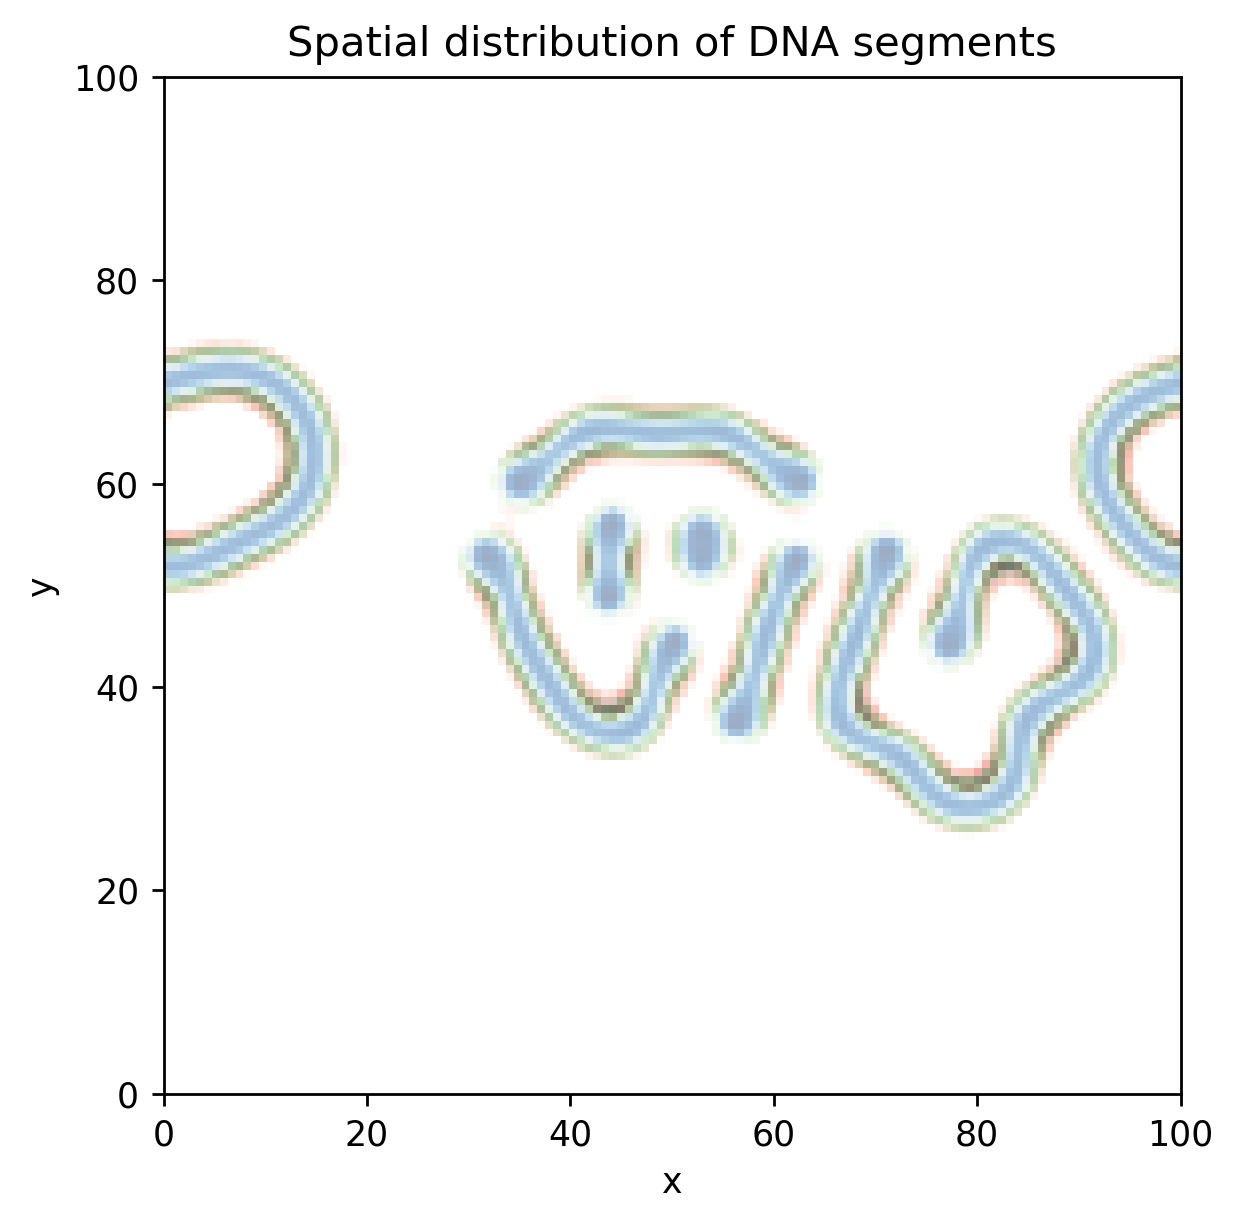

11
24.33


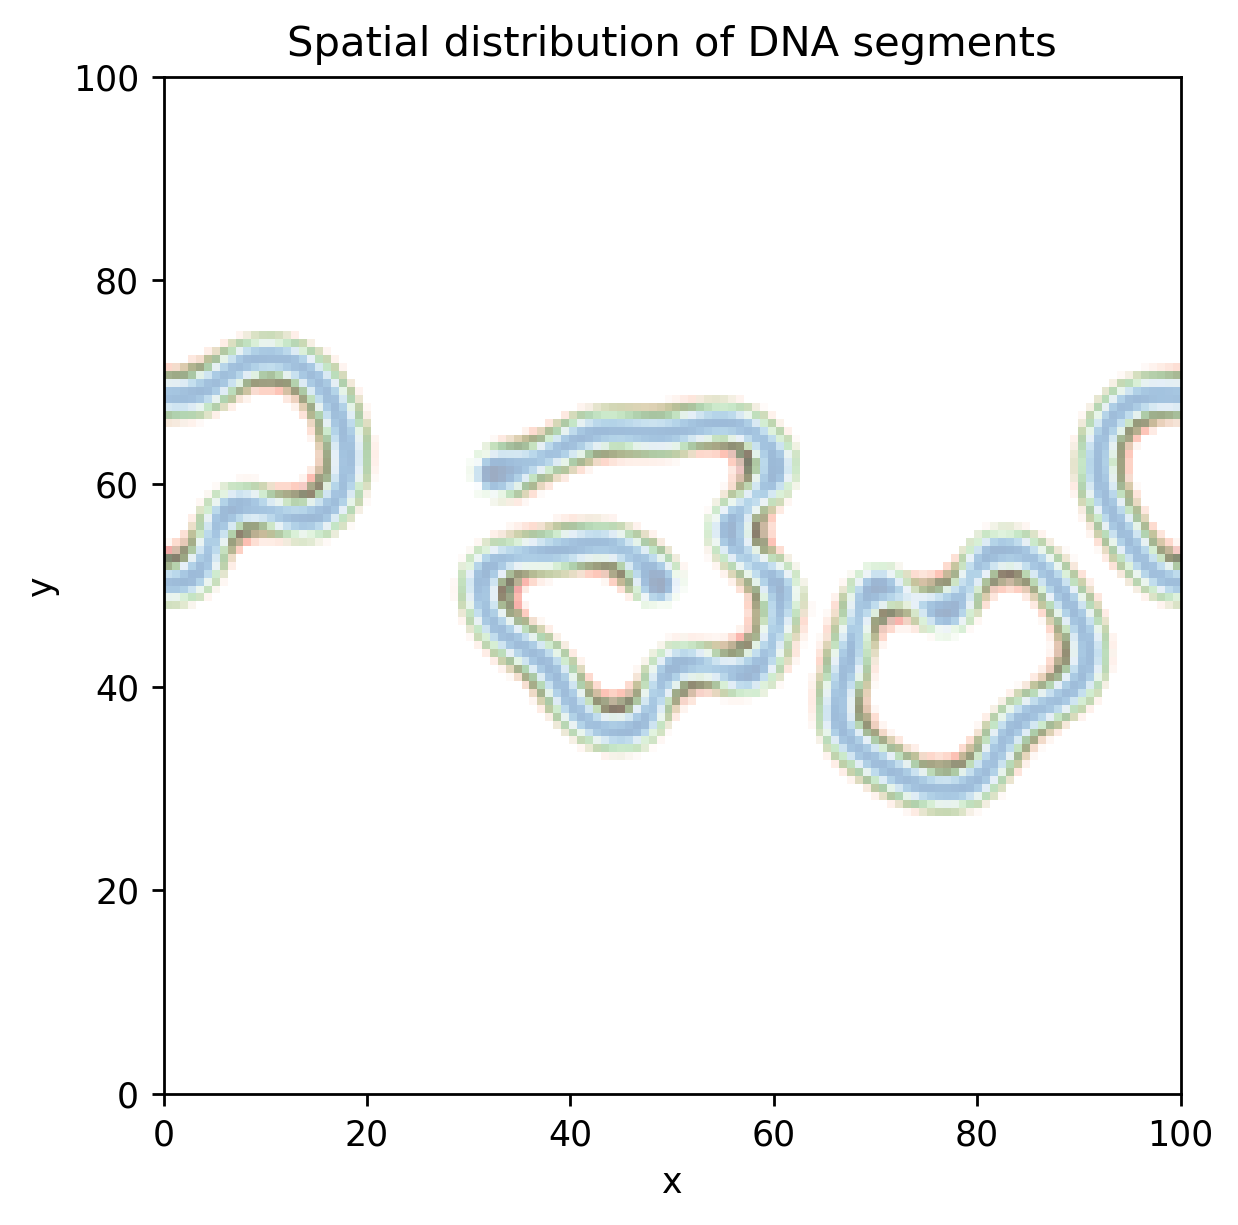

12
24.34


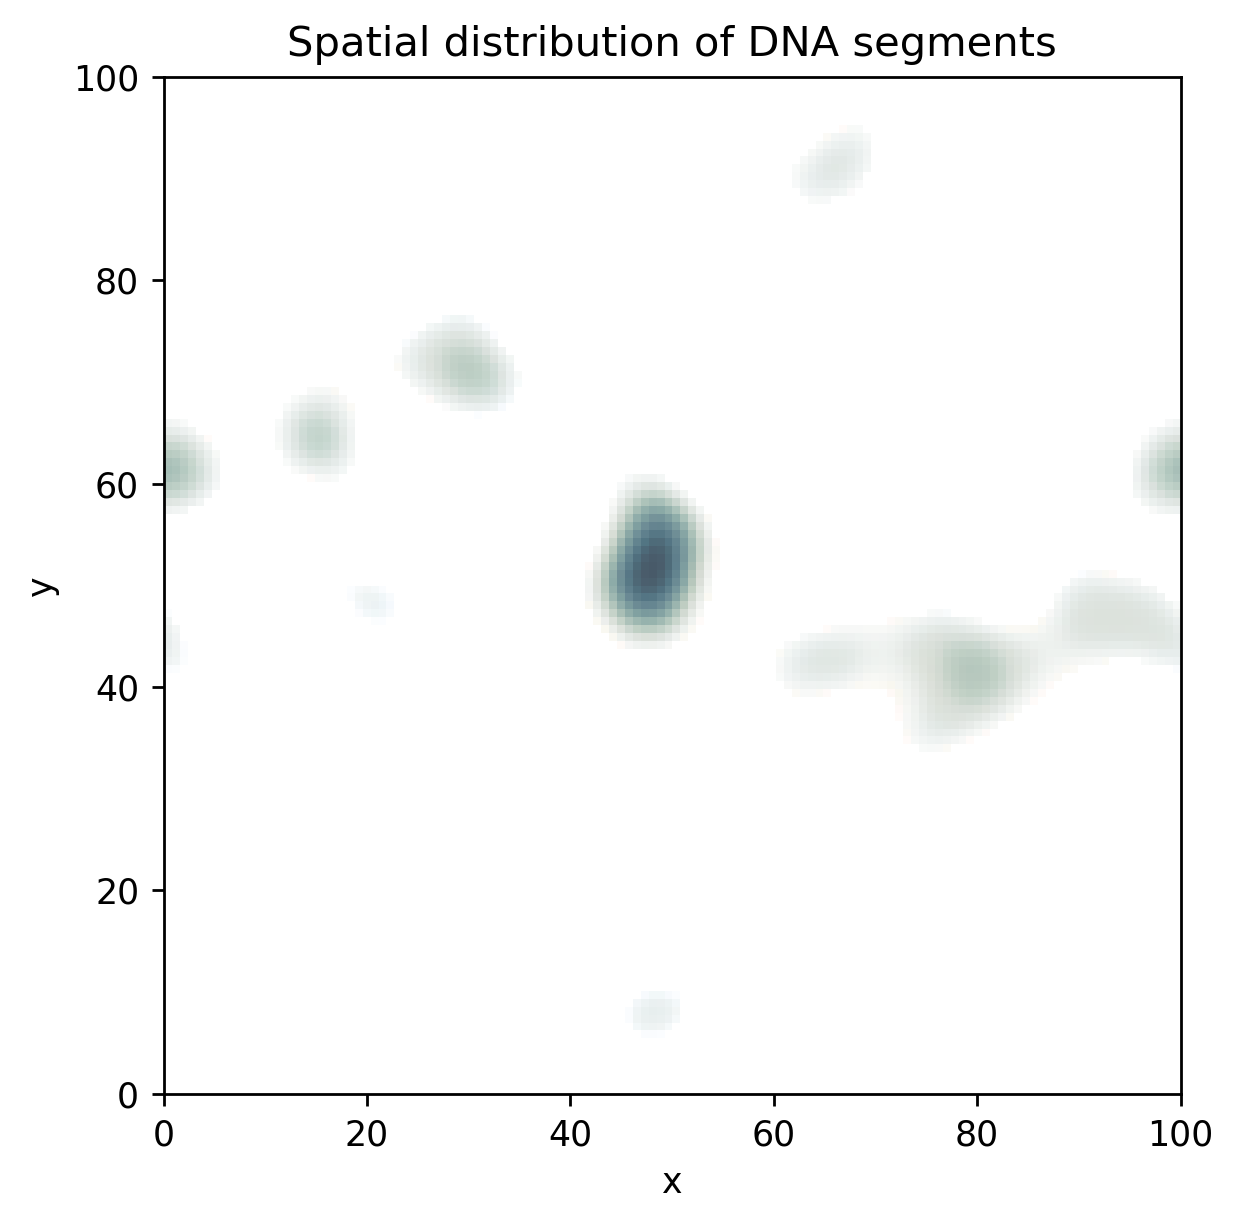

13
24.35


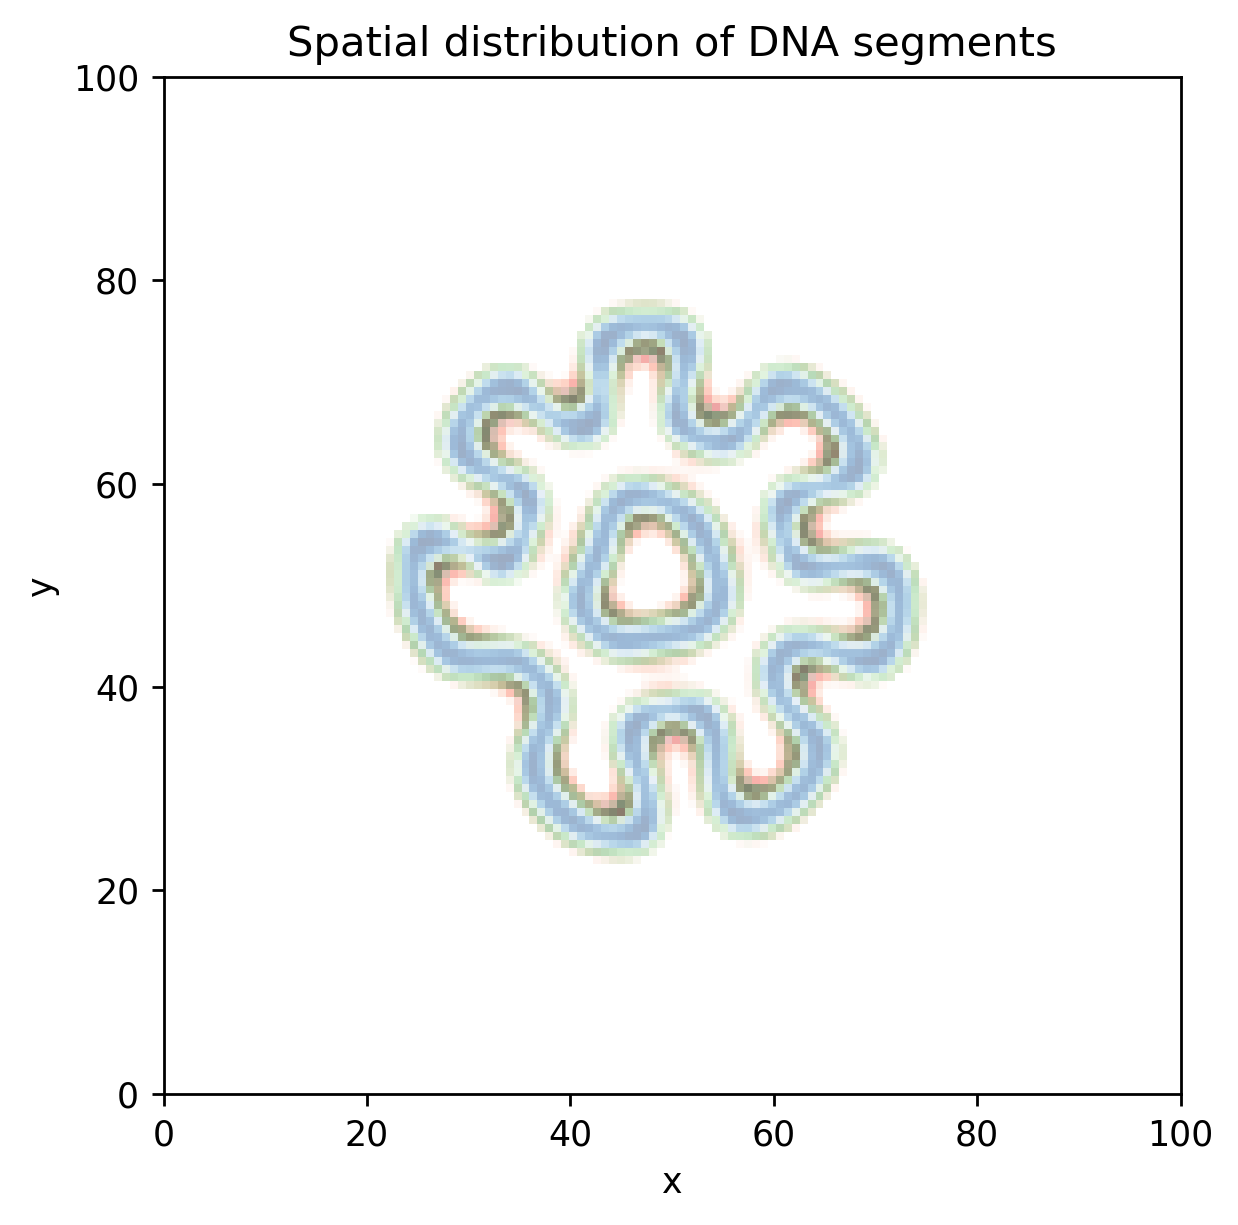

14
24.36


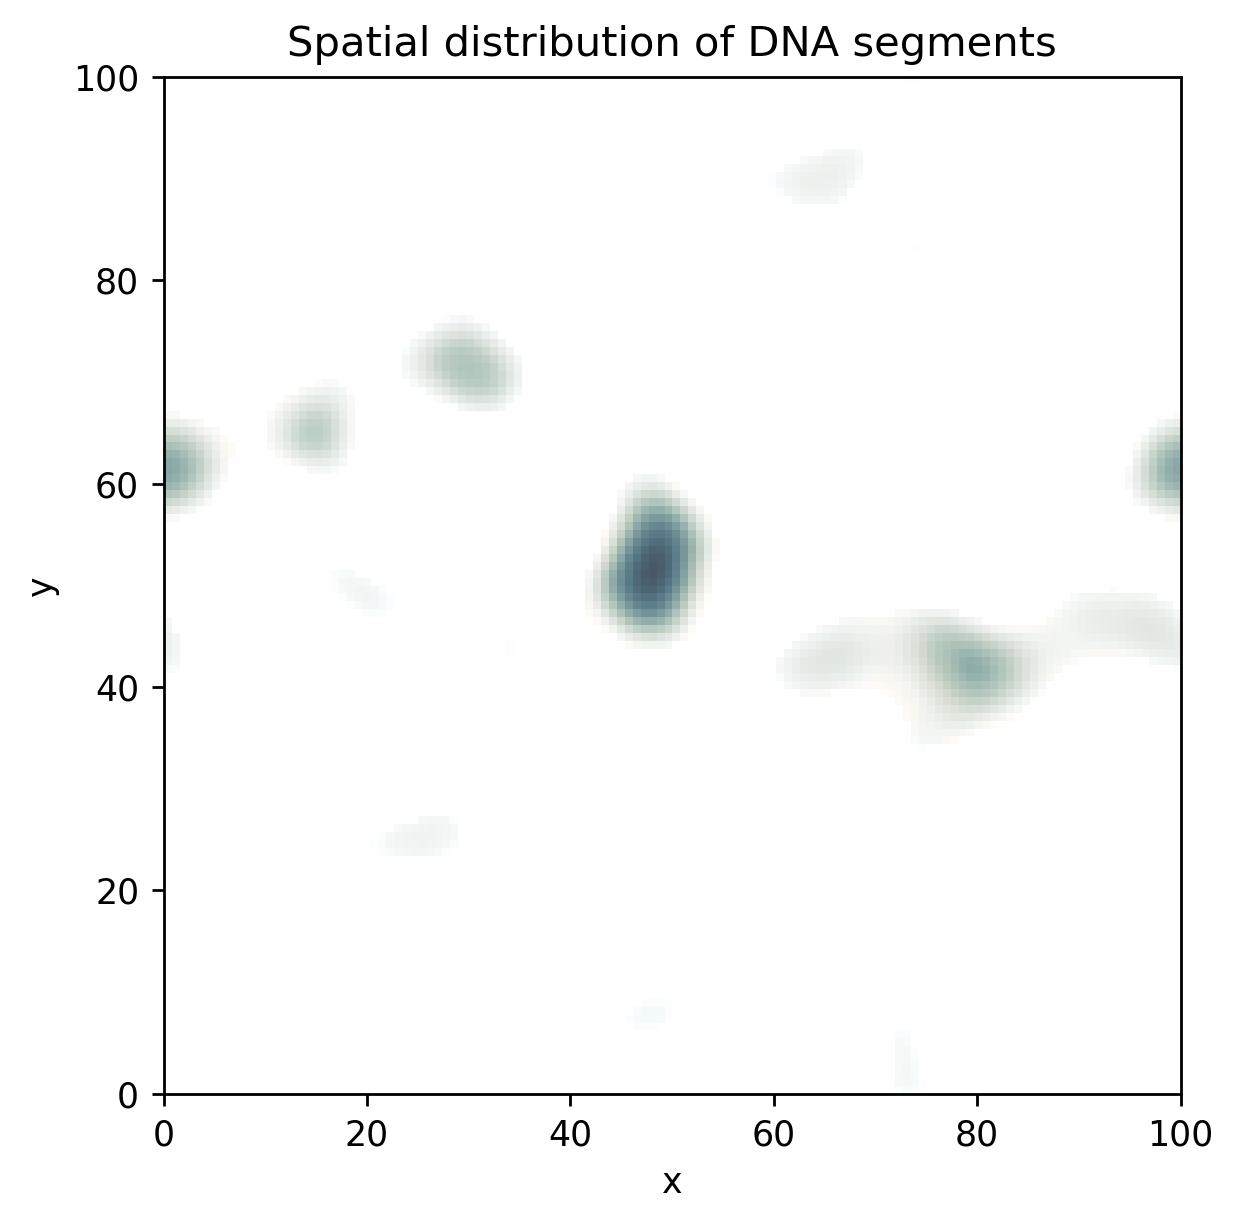

15
24.37


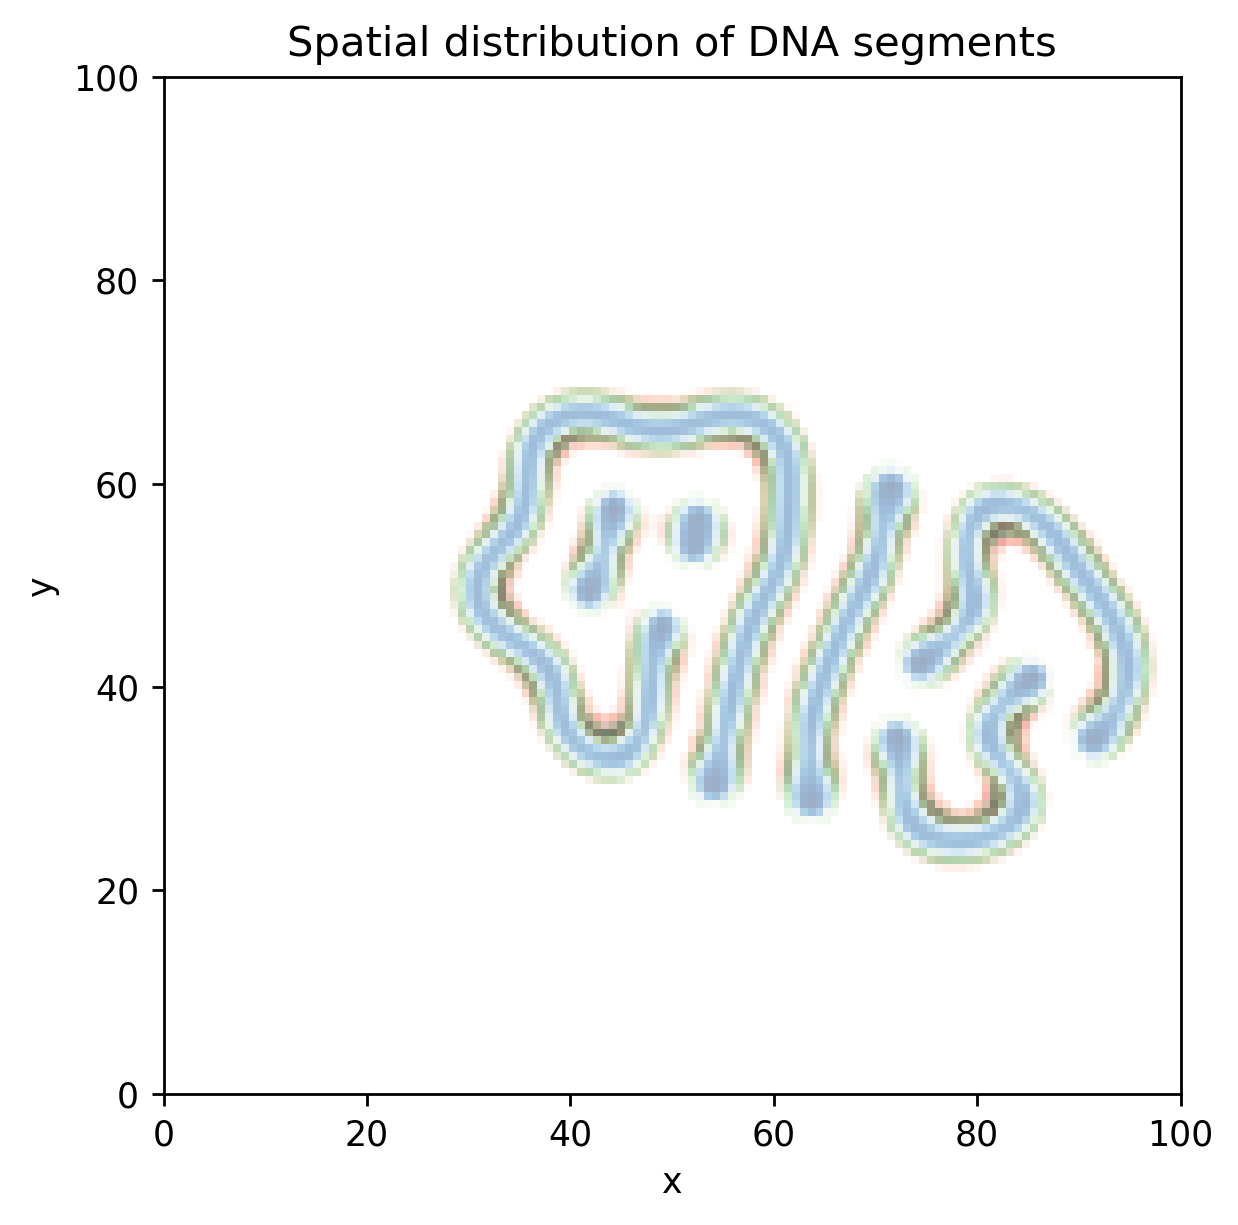

16
24.38


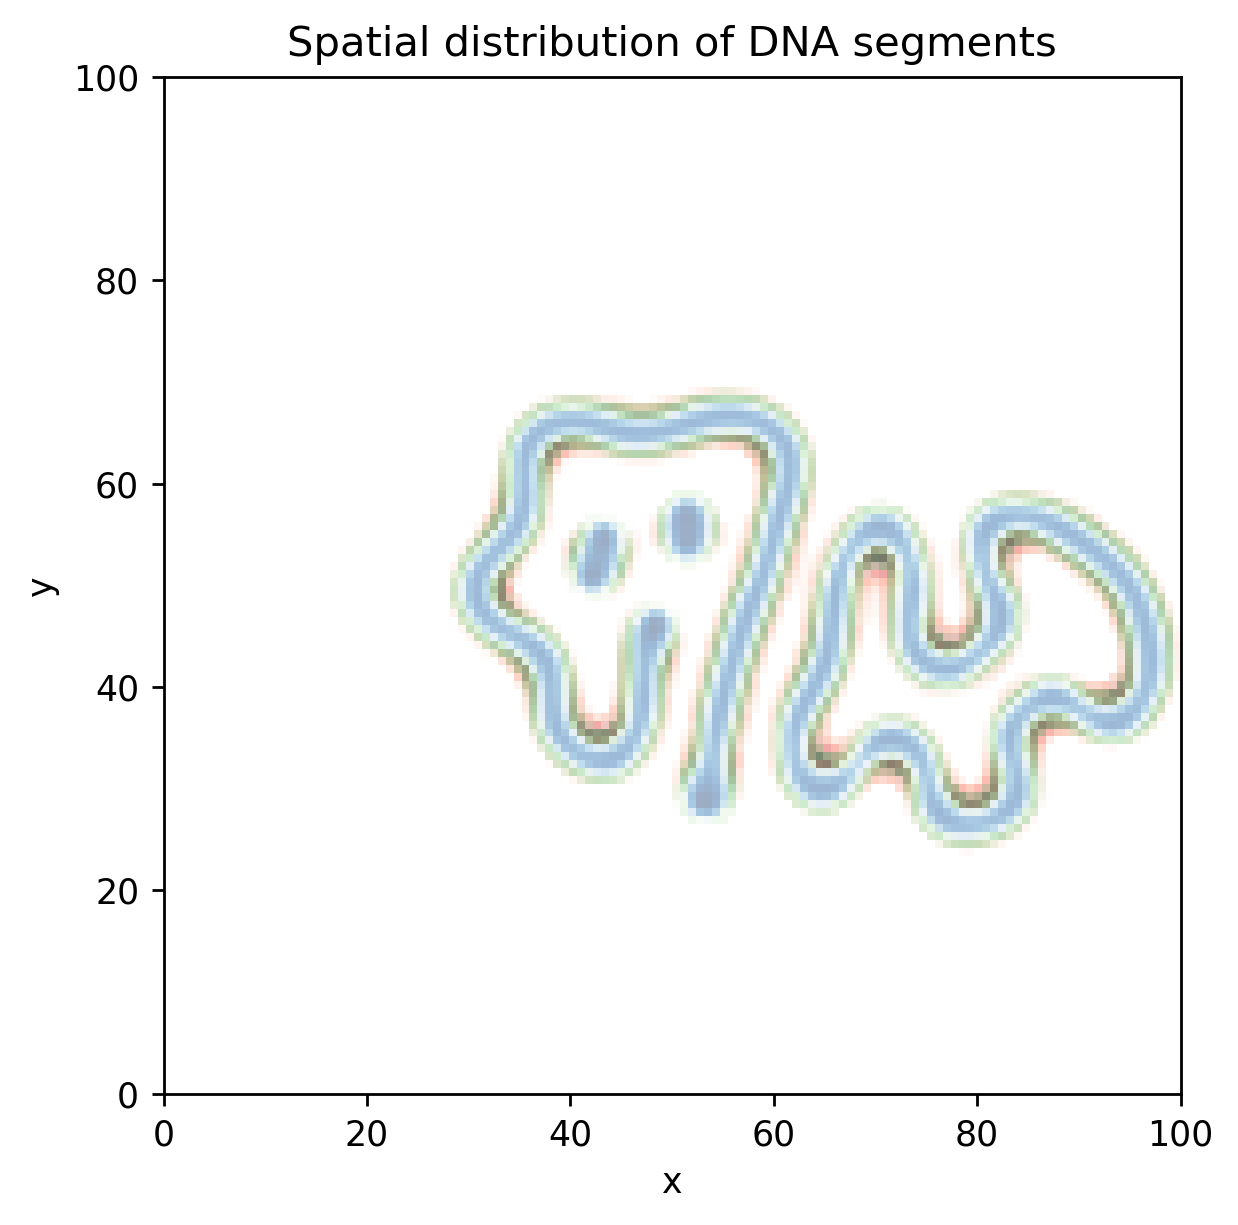

17
24.39


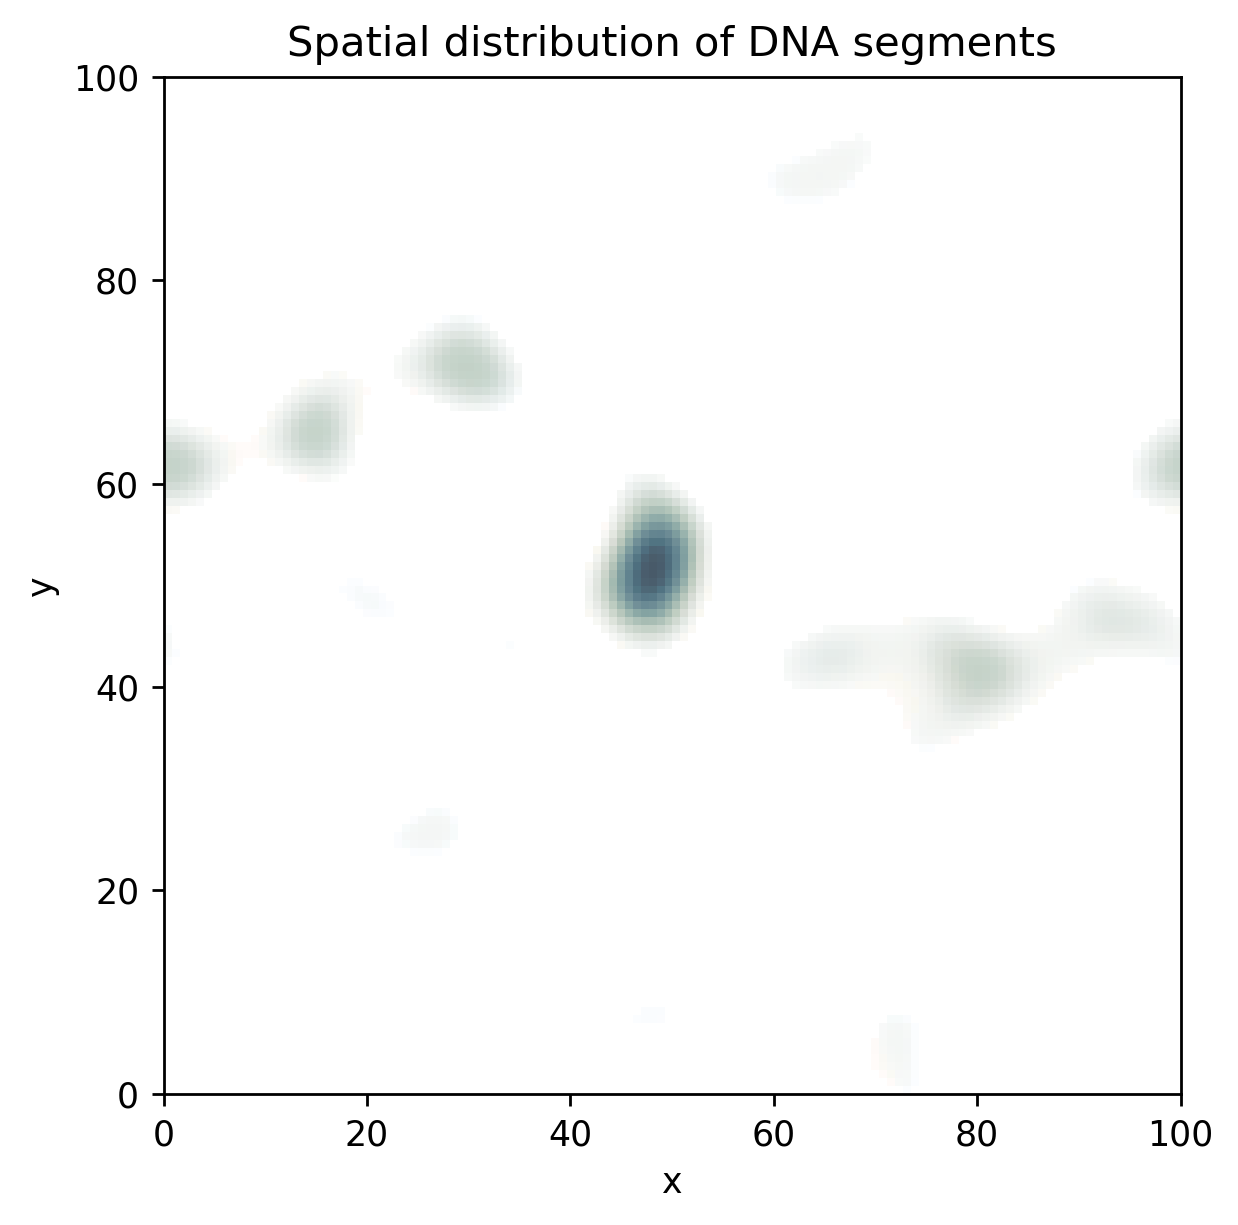

18
24.4


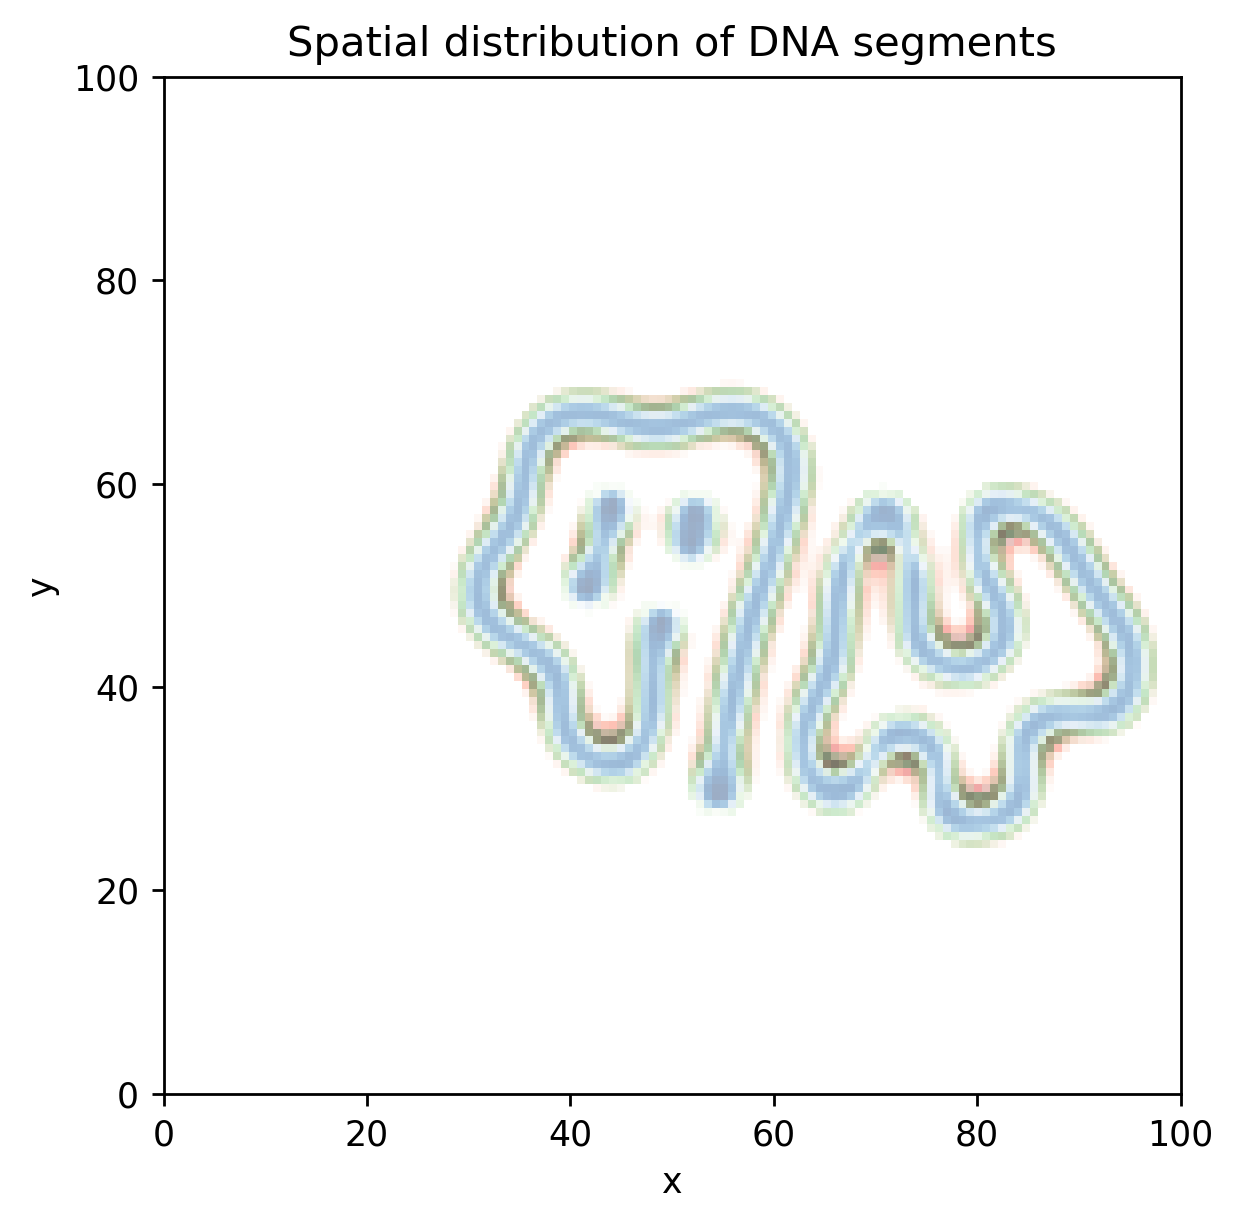

19
24.5


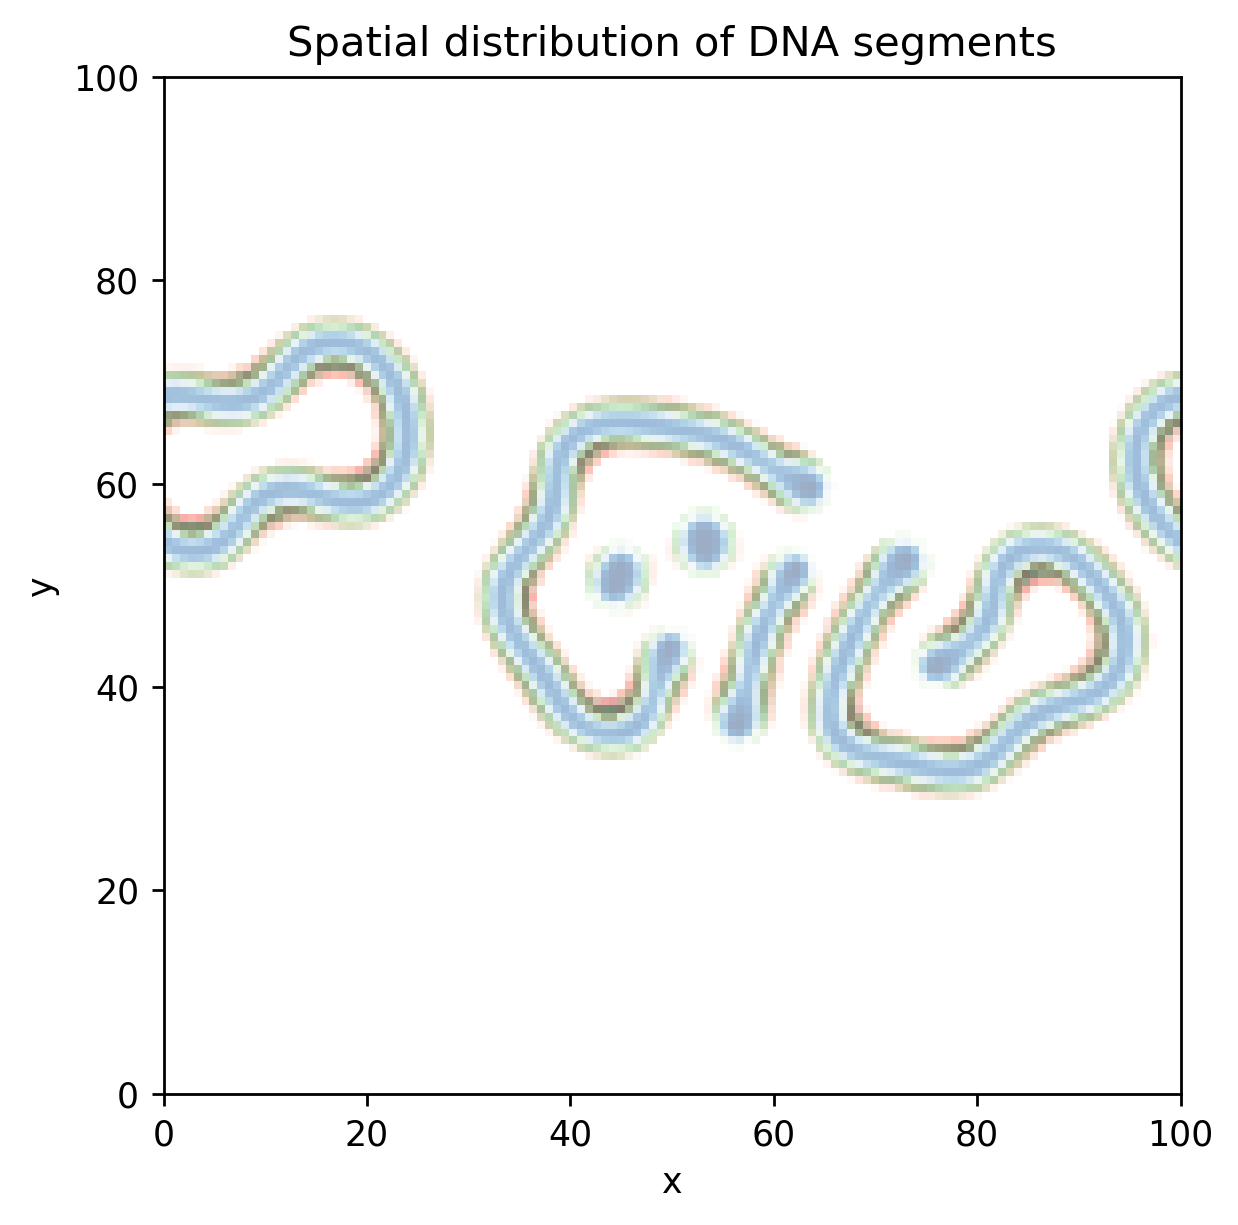

20
25.0


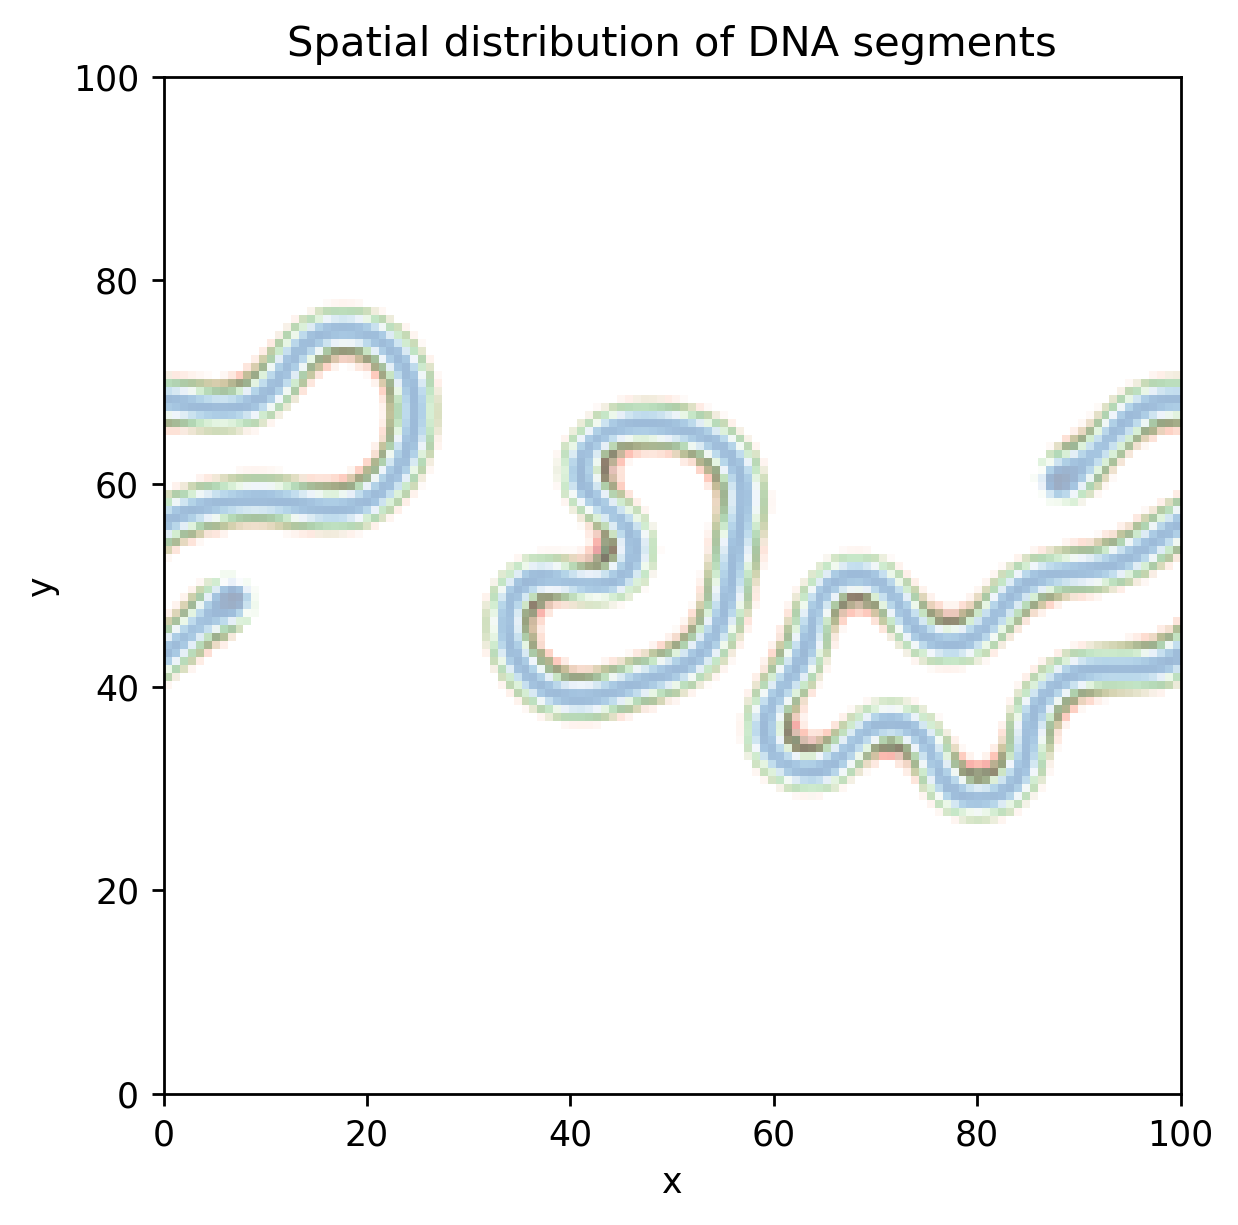

21
25.5


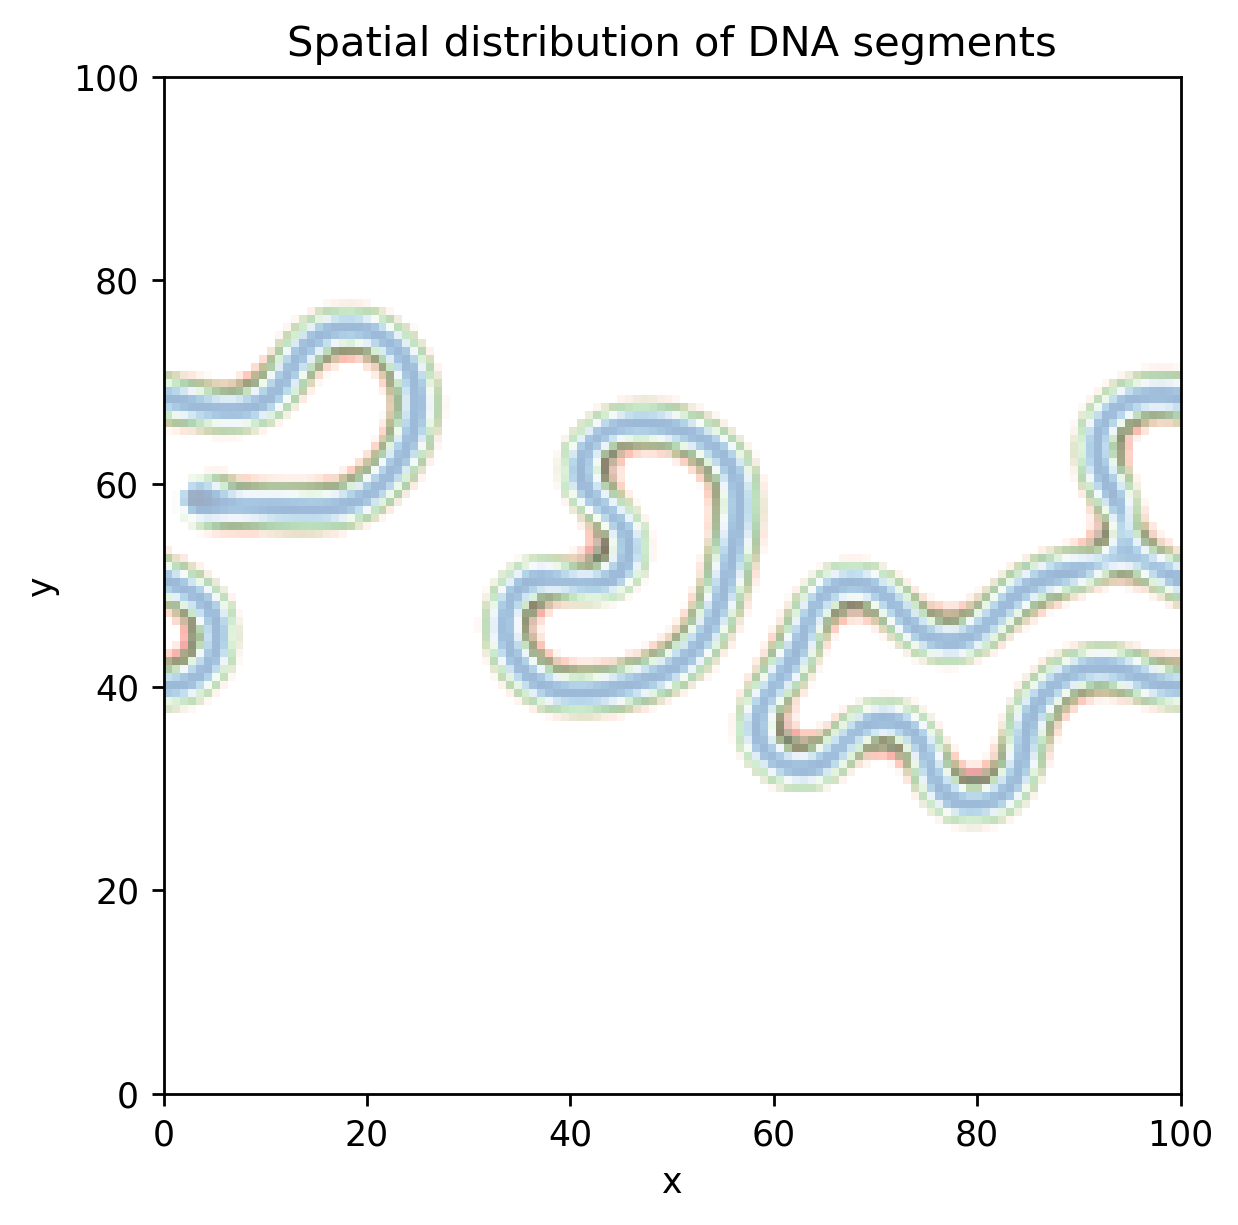

22
26.0


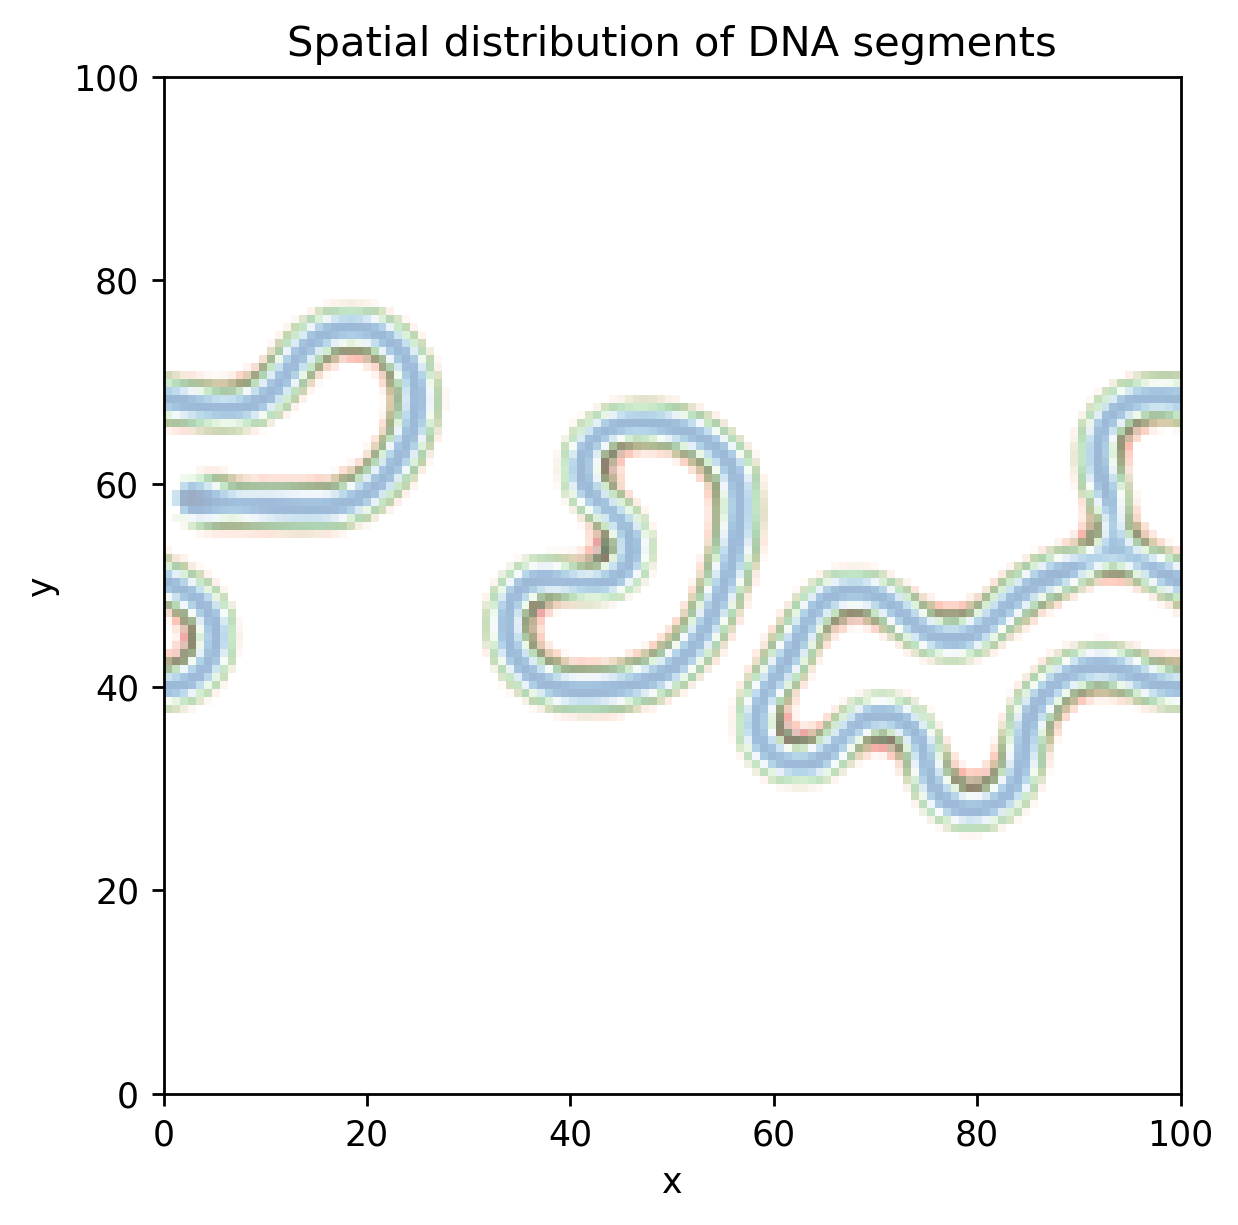

23
27.0


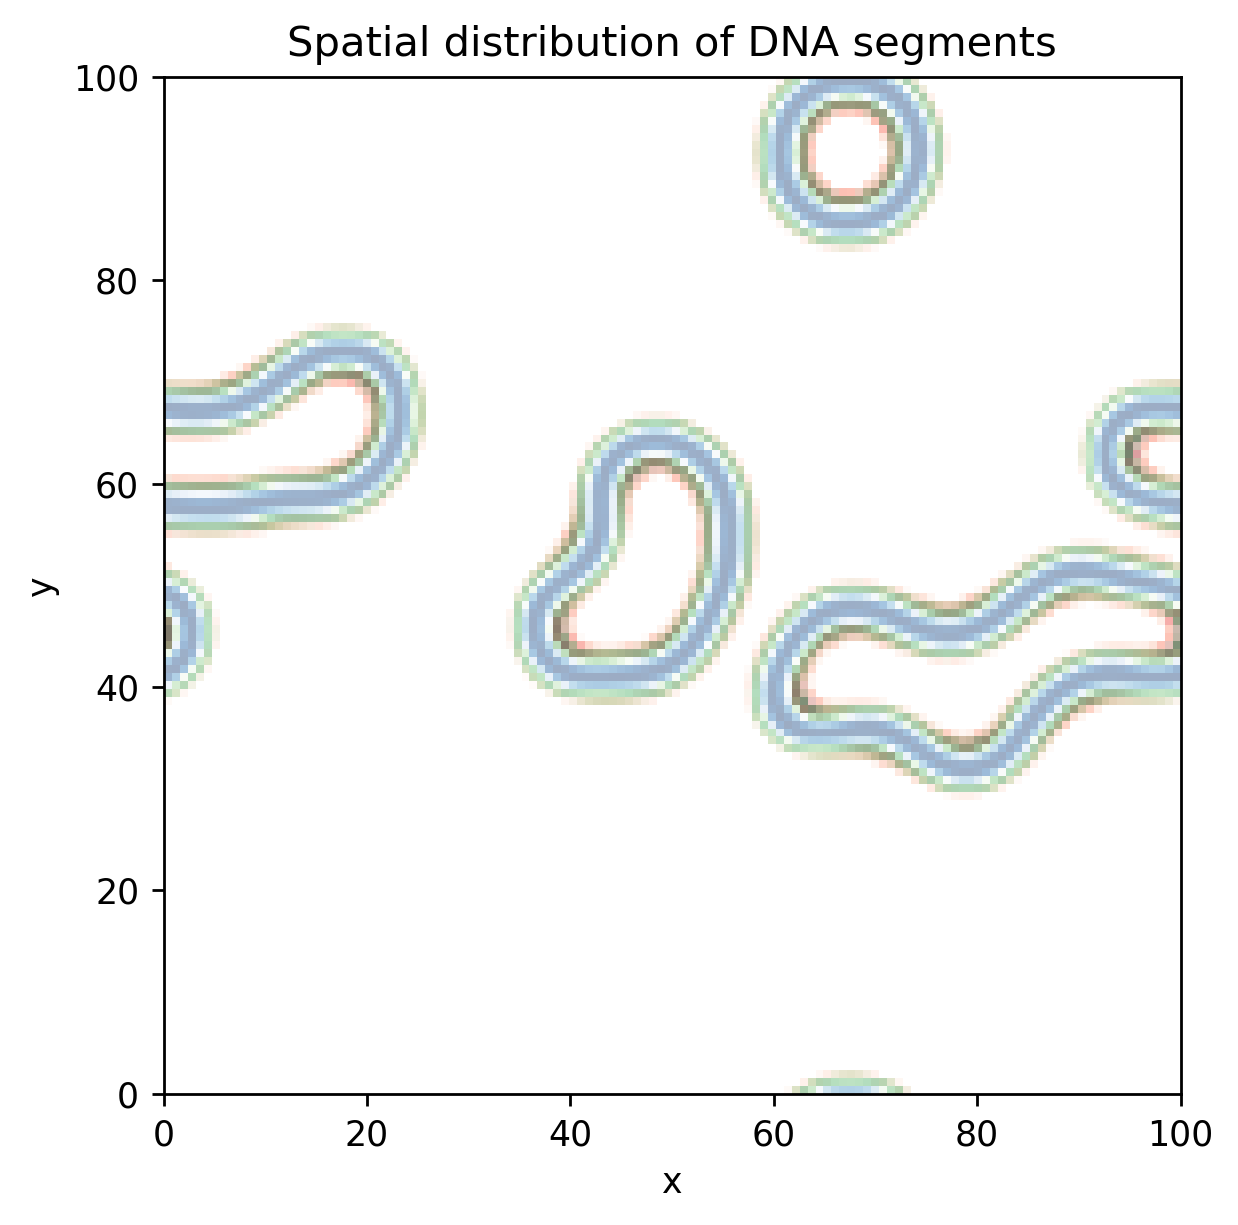

24
28.0


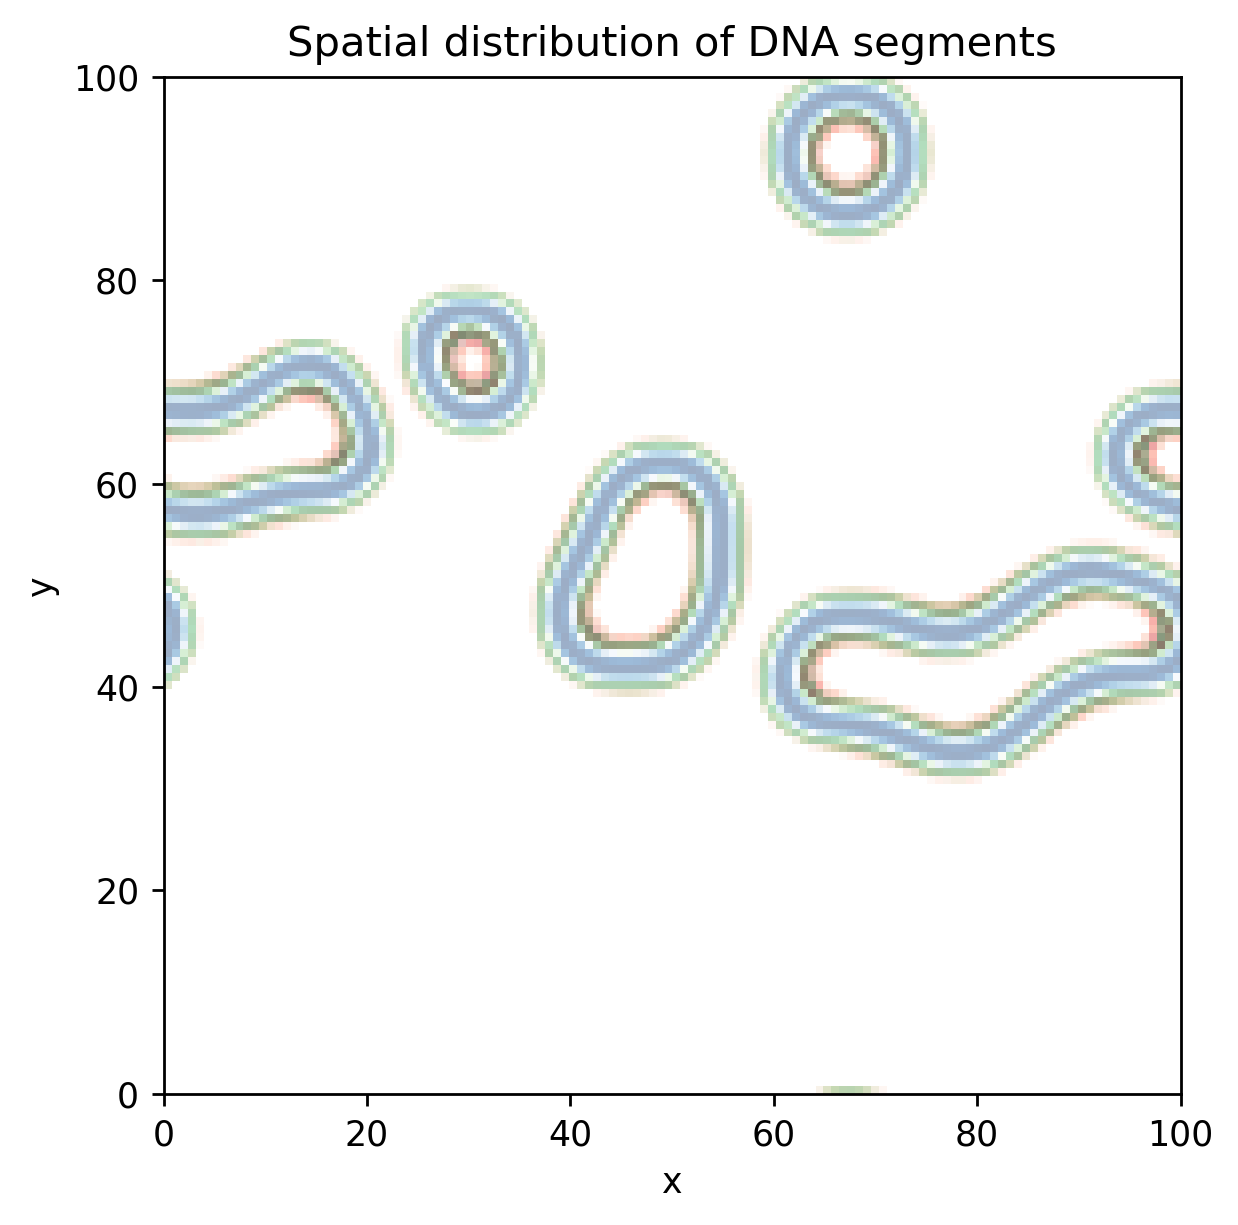

25
29.0


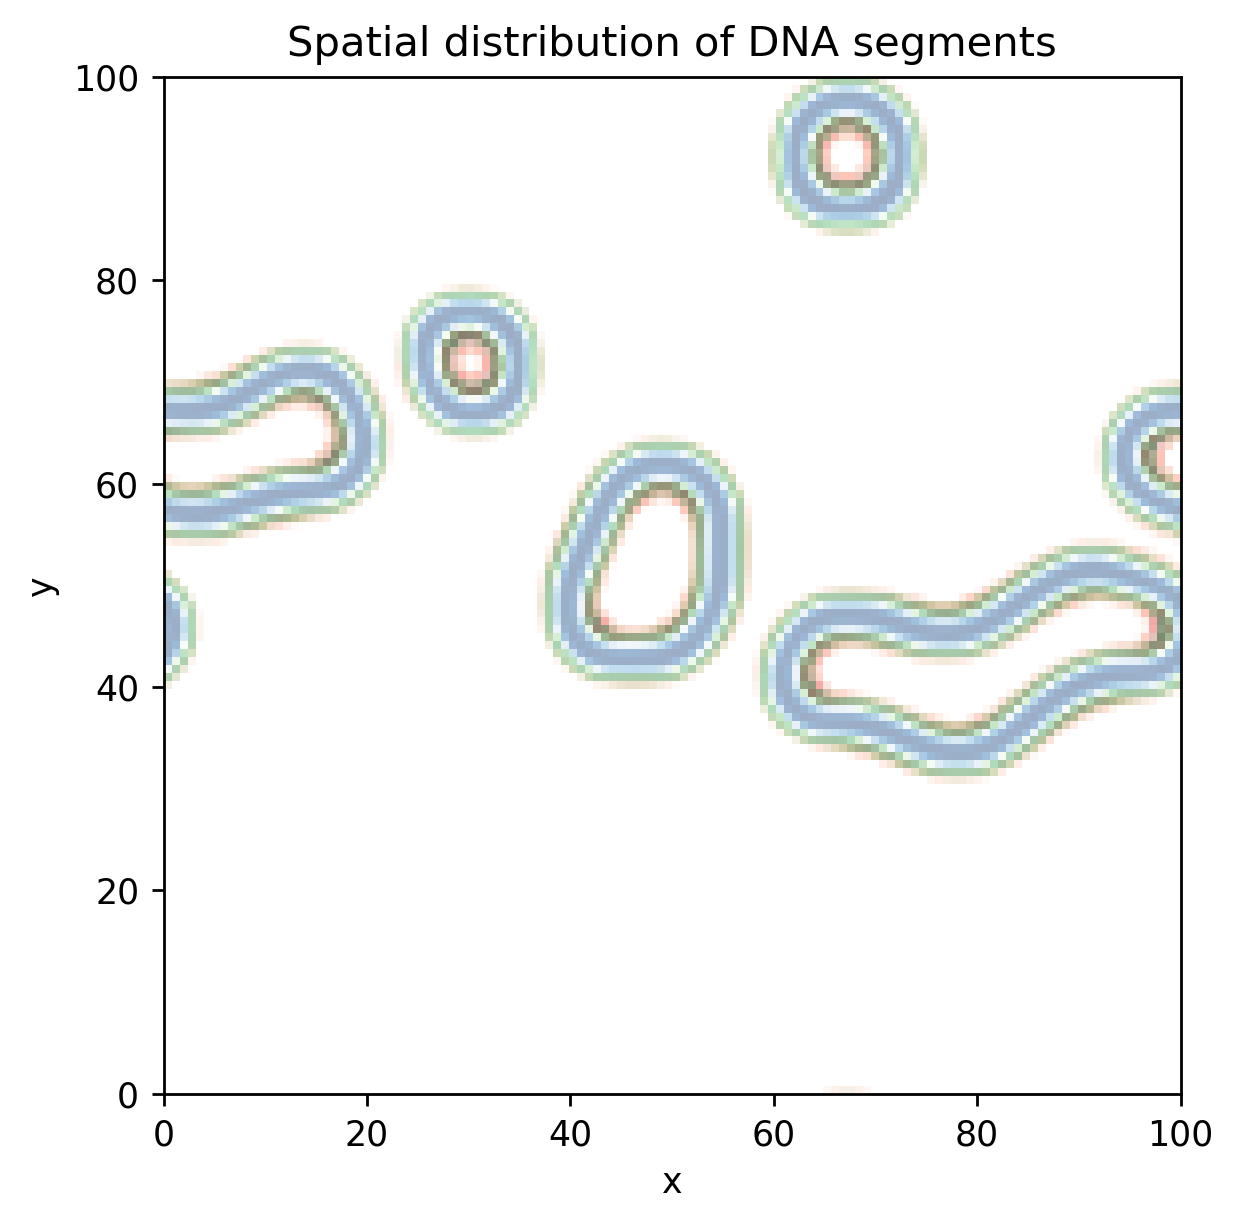

26
30.0


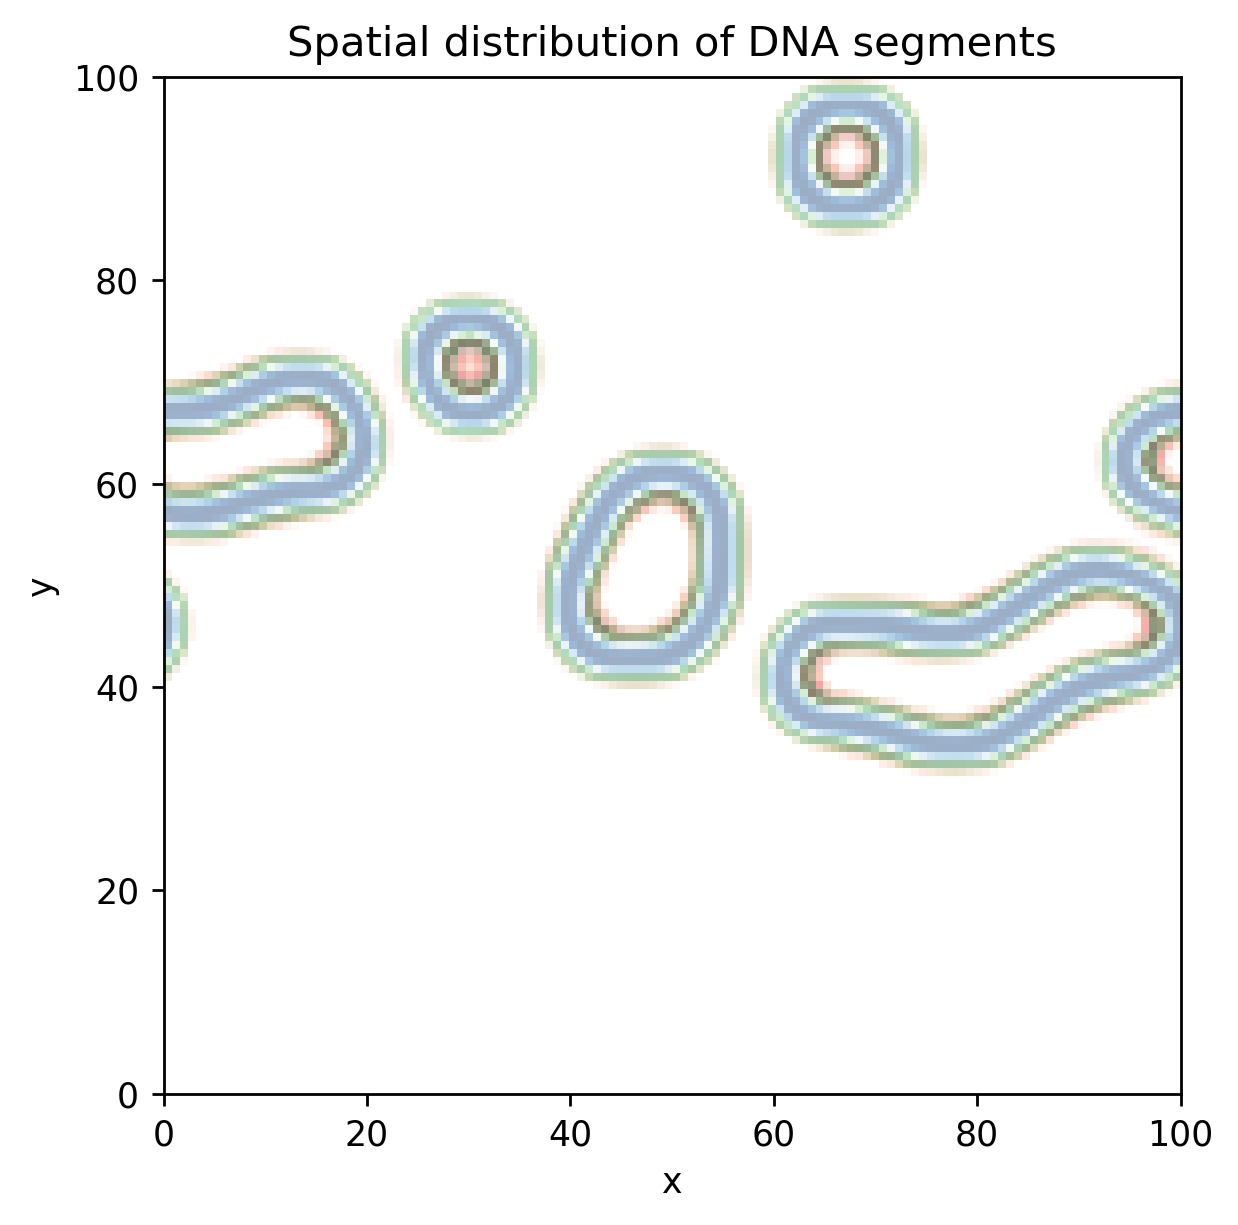

27
32.5


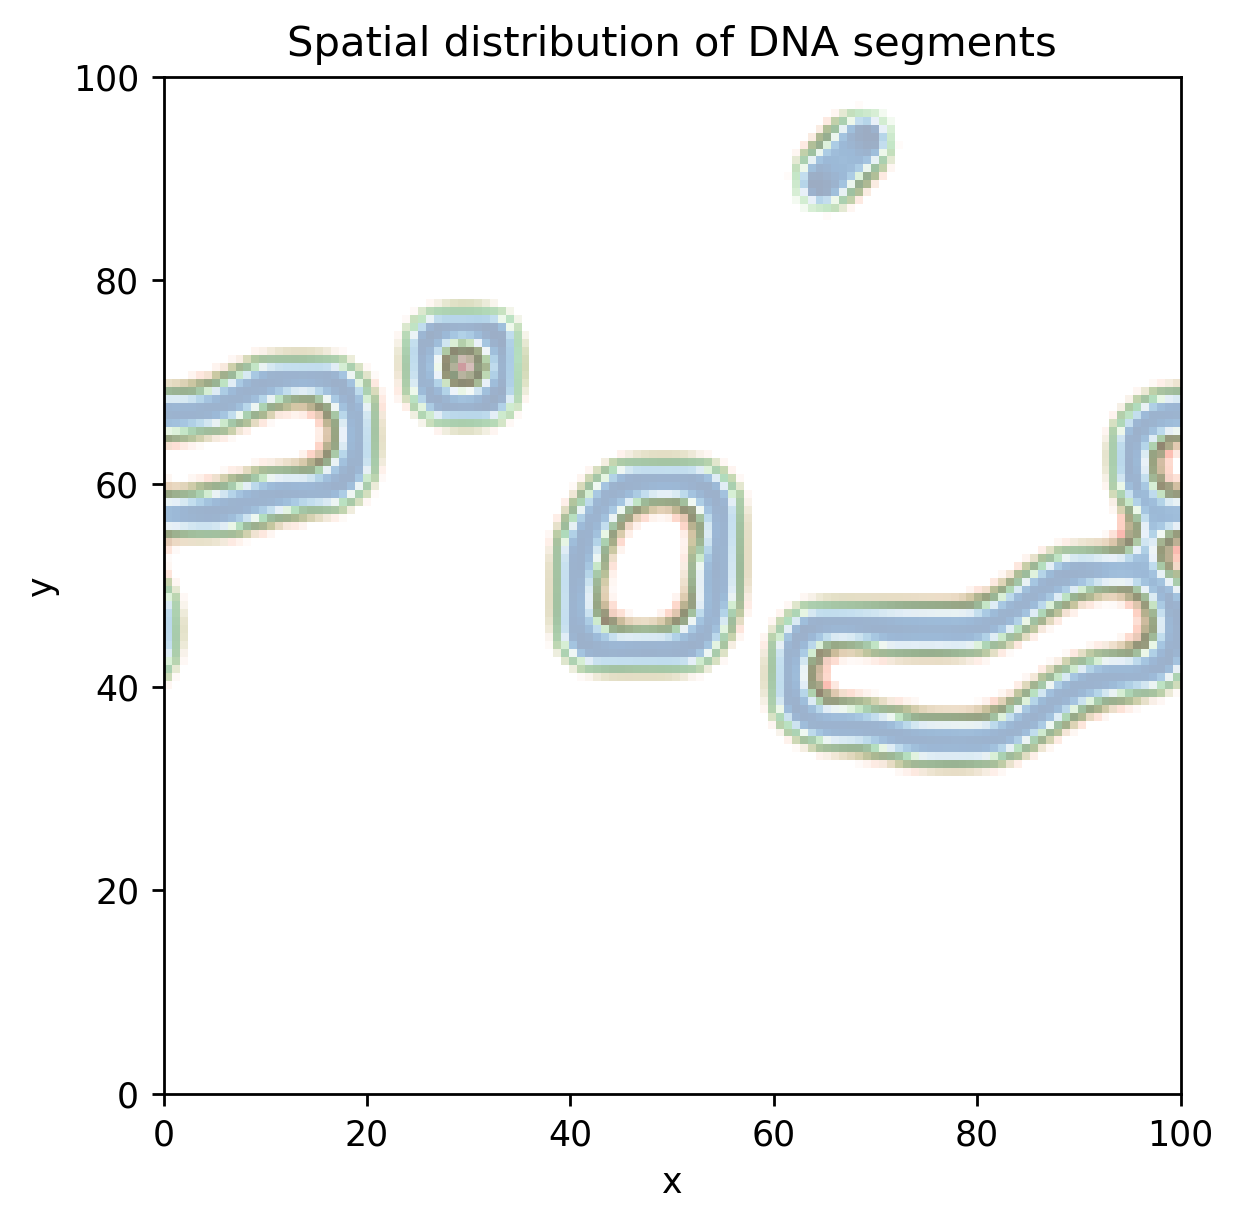

28
35.0


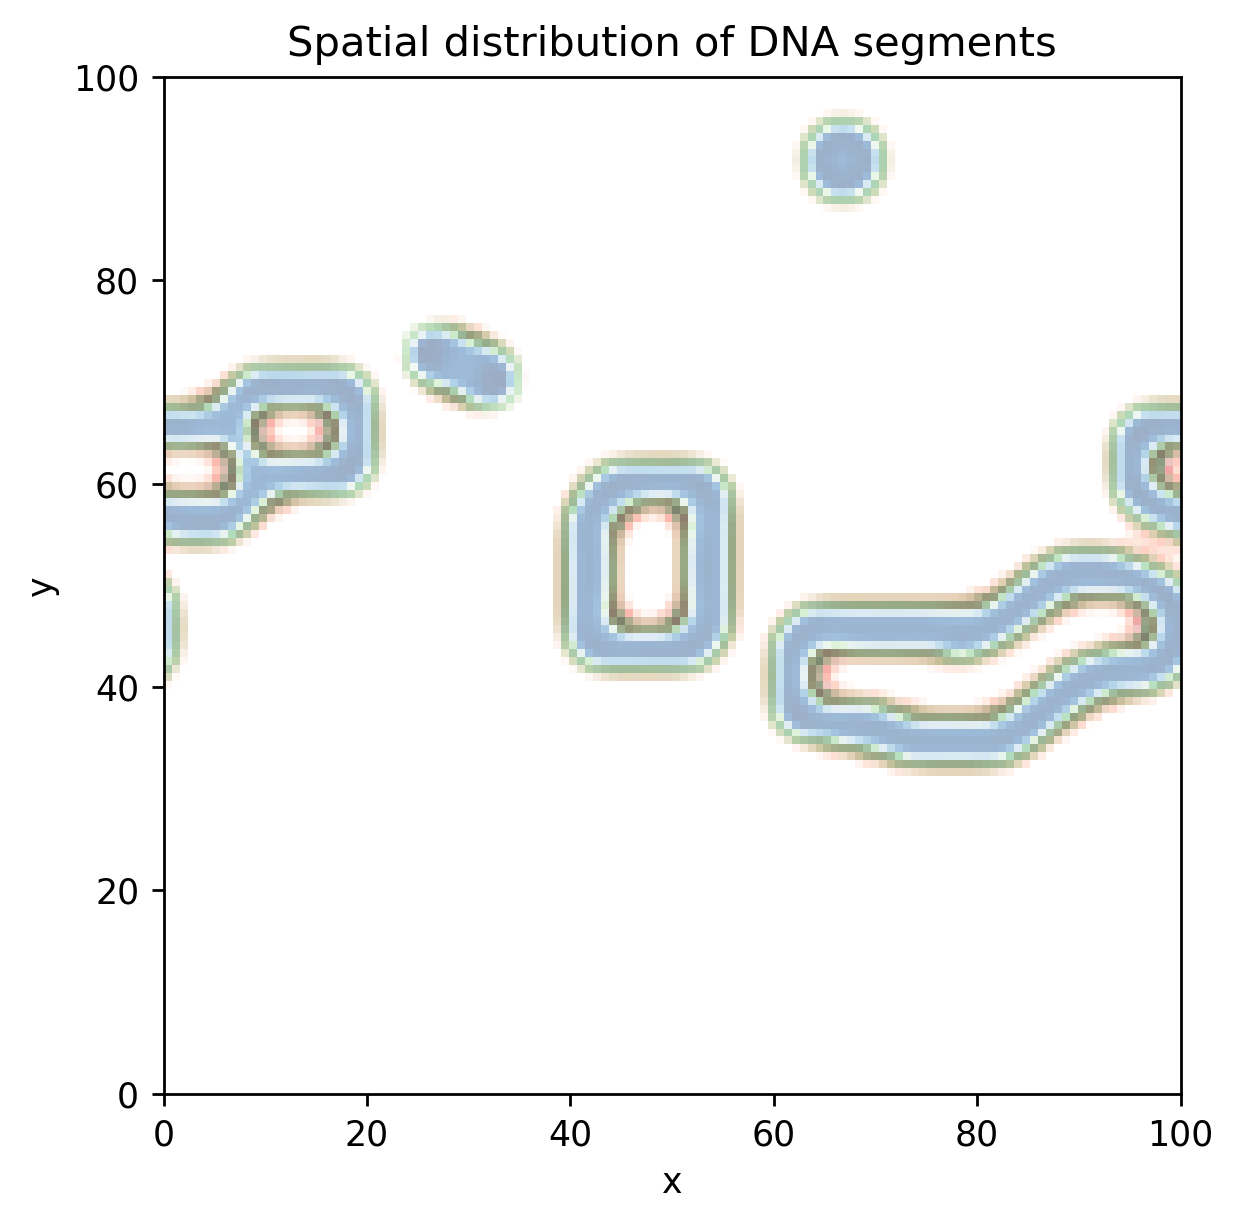

In [8]:
for i in range(len(chi_bs_list)):
    print(i)
    print(chi_bs_list[i])
    plot_phi_blocks_periodic(
                phi_list[i],
                extent=(0, L, 0, L),
                percentile=92,
                shift_x=0,
                shift_y=0,
            )

0
18.0


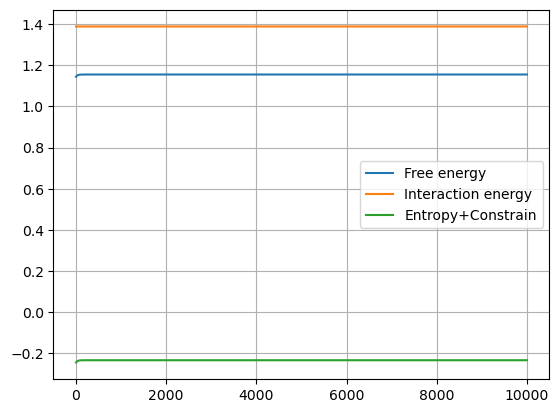

1
20.0


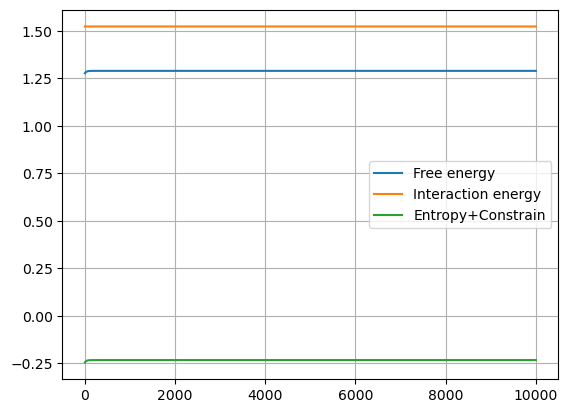

2
22.0


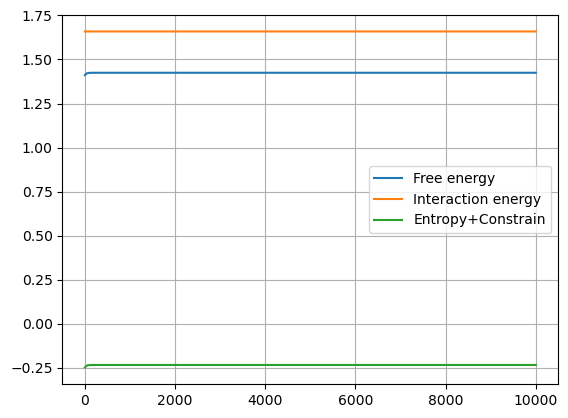

3
23.0


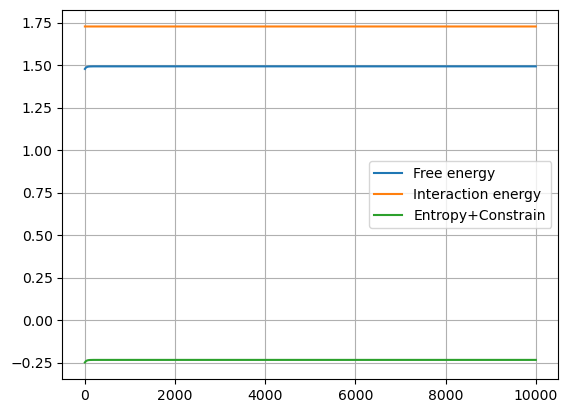

4
23.5


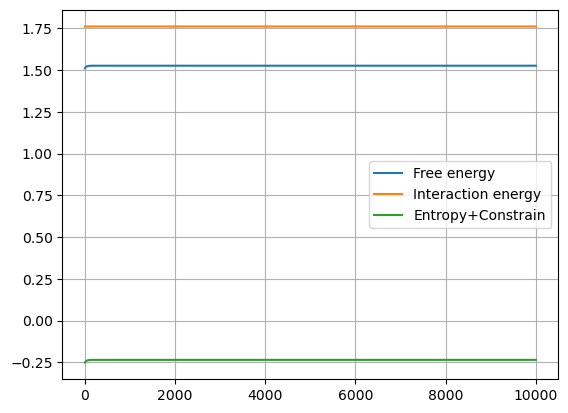

5
24.0


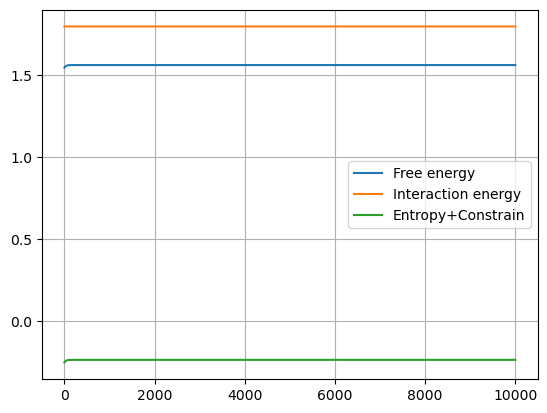

6
24.1


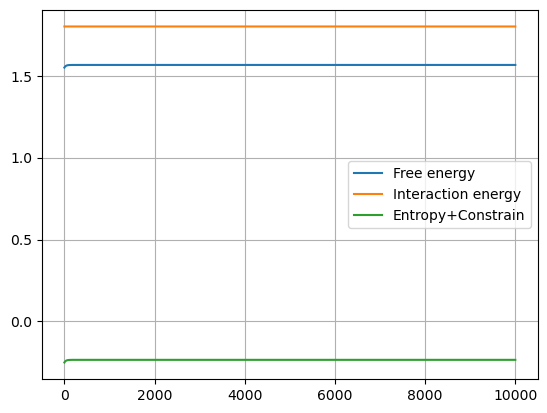

7
24.2


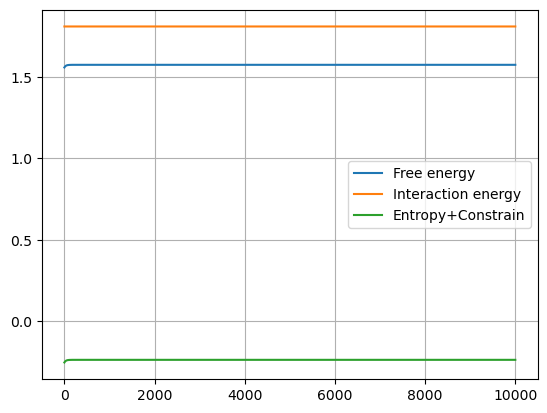

8
24.3


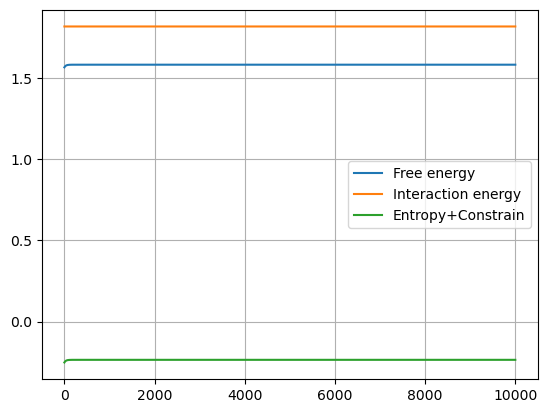

9
24.32


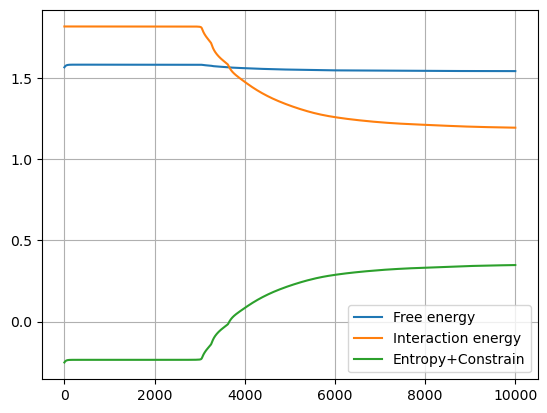

10
24.32


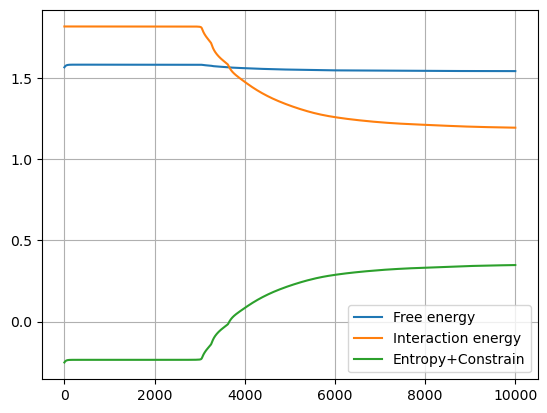

11
24.33


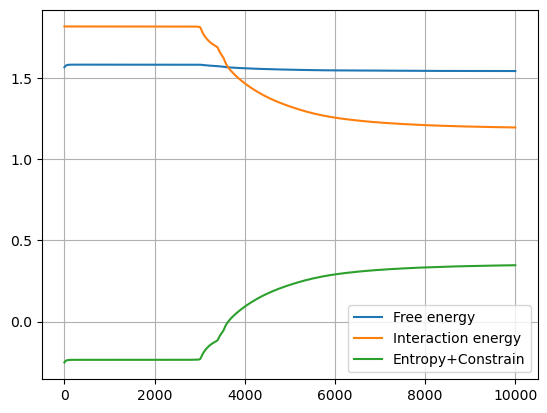

12
24.34


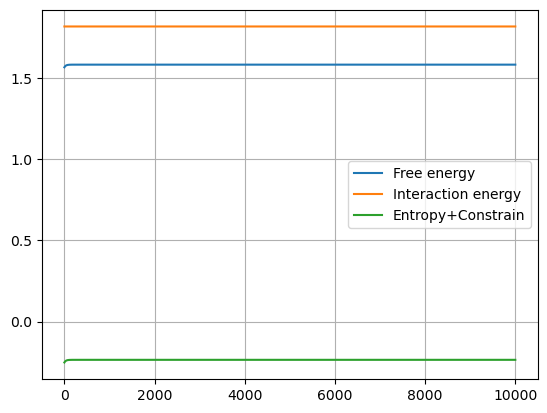

13
24.35


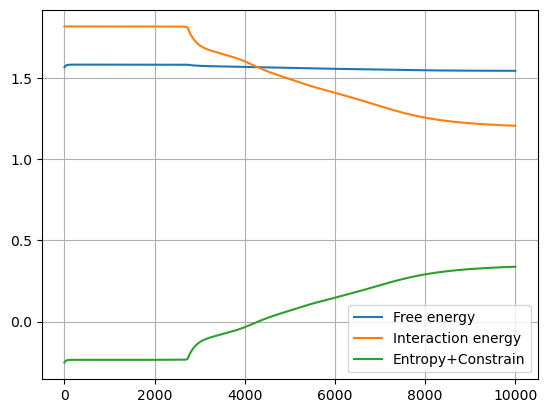

14
24.36


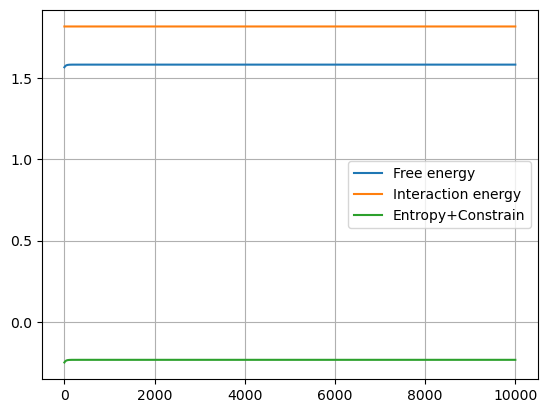

15
24.37


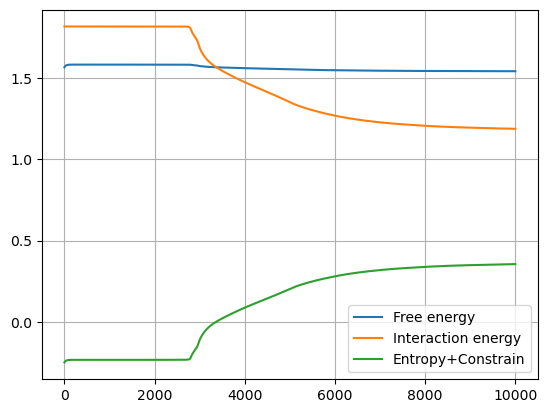

16
24.38


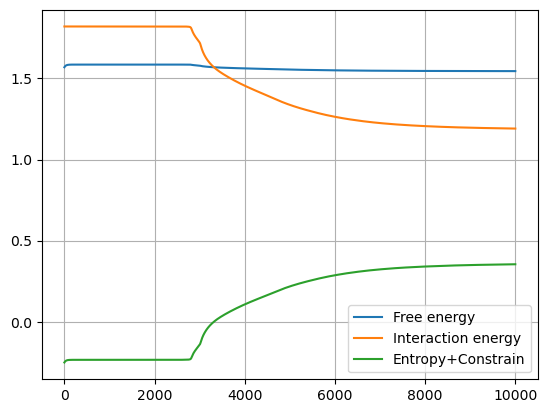

17
24.39


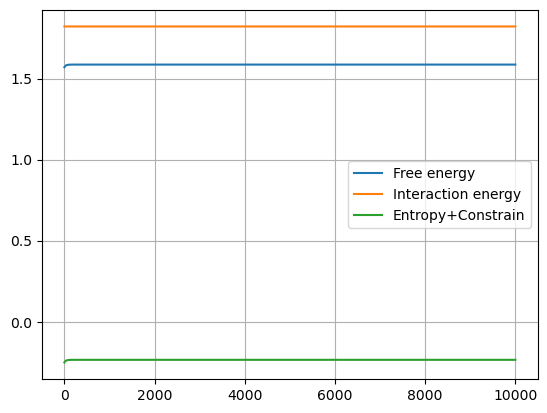

18
24.4


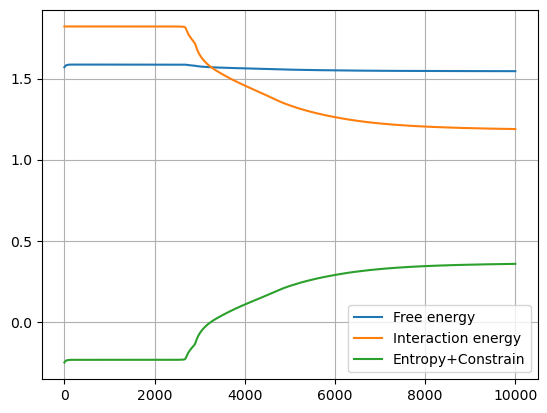

19
24.5


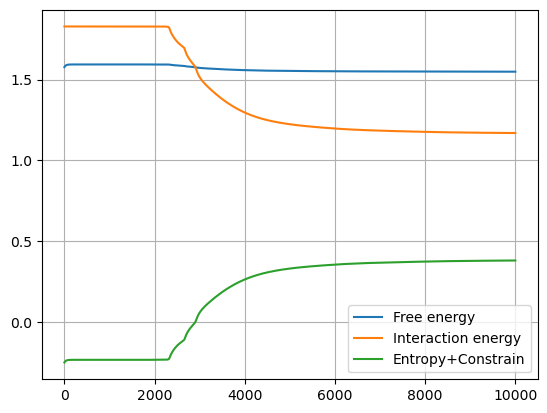

20
25.0


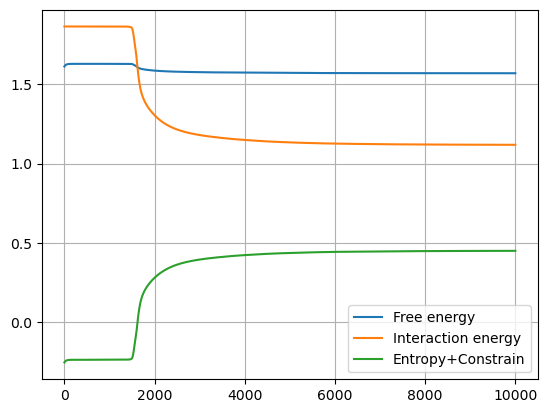

21
25.5


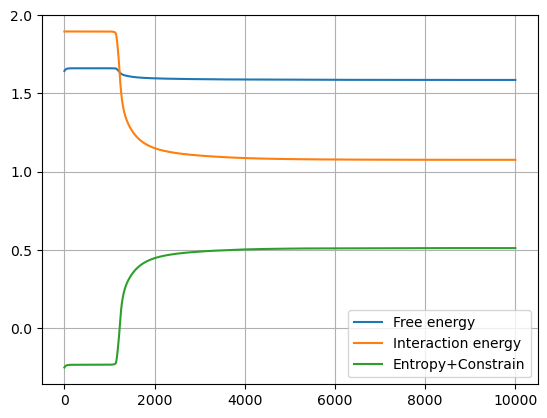

22
26.0


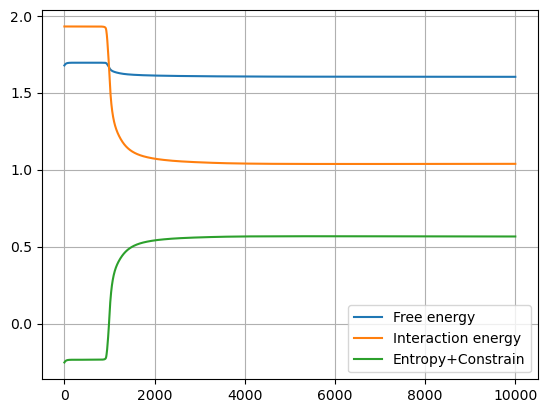

23
27.0


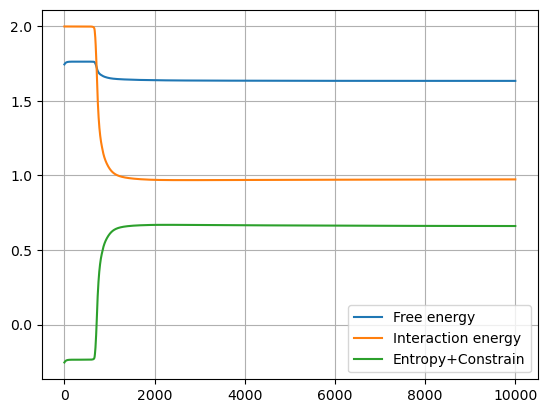

24
28.0


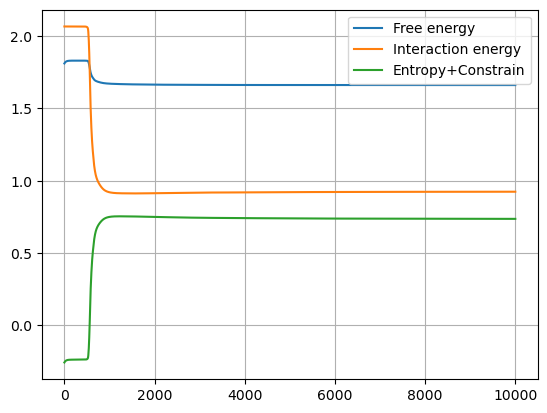

25
29.0


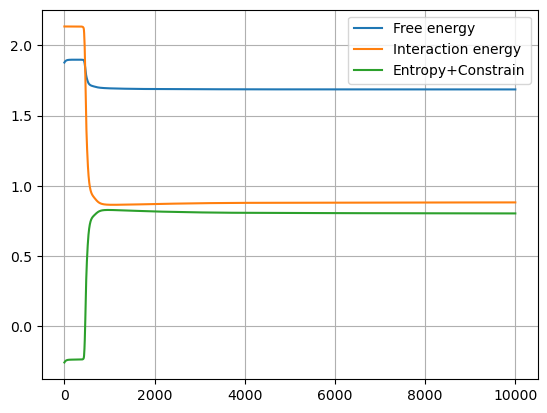

26
30.0


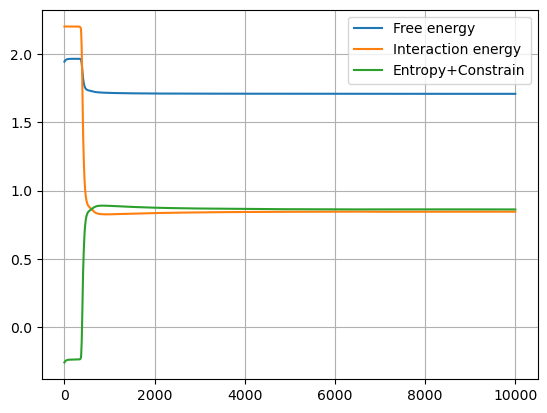

27
32.5


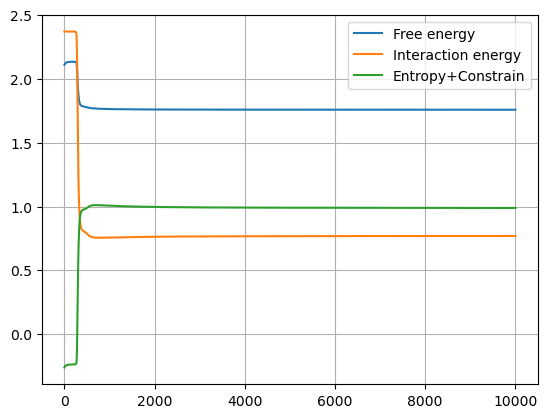

28
35.0


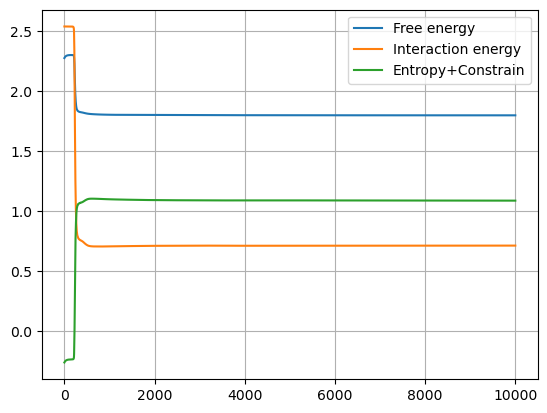

In [12]:
final_energy = np.zeros((len(chi_bs_list),3))
for i in range(len(chi_bs_list)):
    print(i)
    print(chi_bs_list[i])
    free_energy = np.array(free_energy_hist[i])
    plt.plot(free_energy[:, 0],label="Free energy")
    plt.plot(free_energy[:, 1],label="Interaction energy")
    plt.plot(free_energy[:, 2],label="Entropy+Constrain")
    plt.legend()
    plt.grid()
    plt.show()

    final_energy[i,:] = free_energy[-1, :]

Text(0, 0.5, 'Free energy')

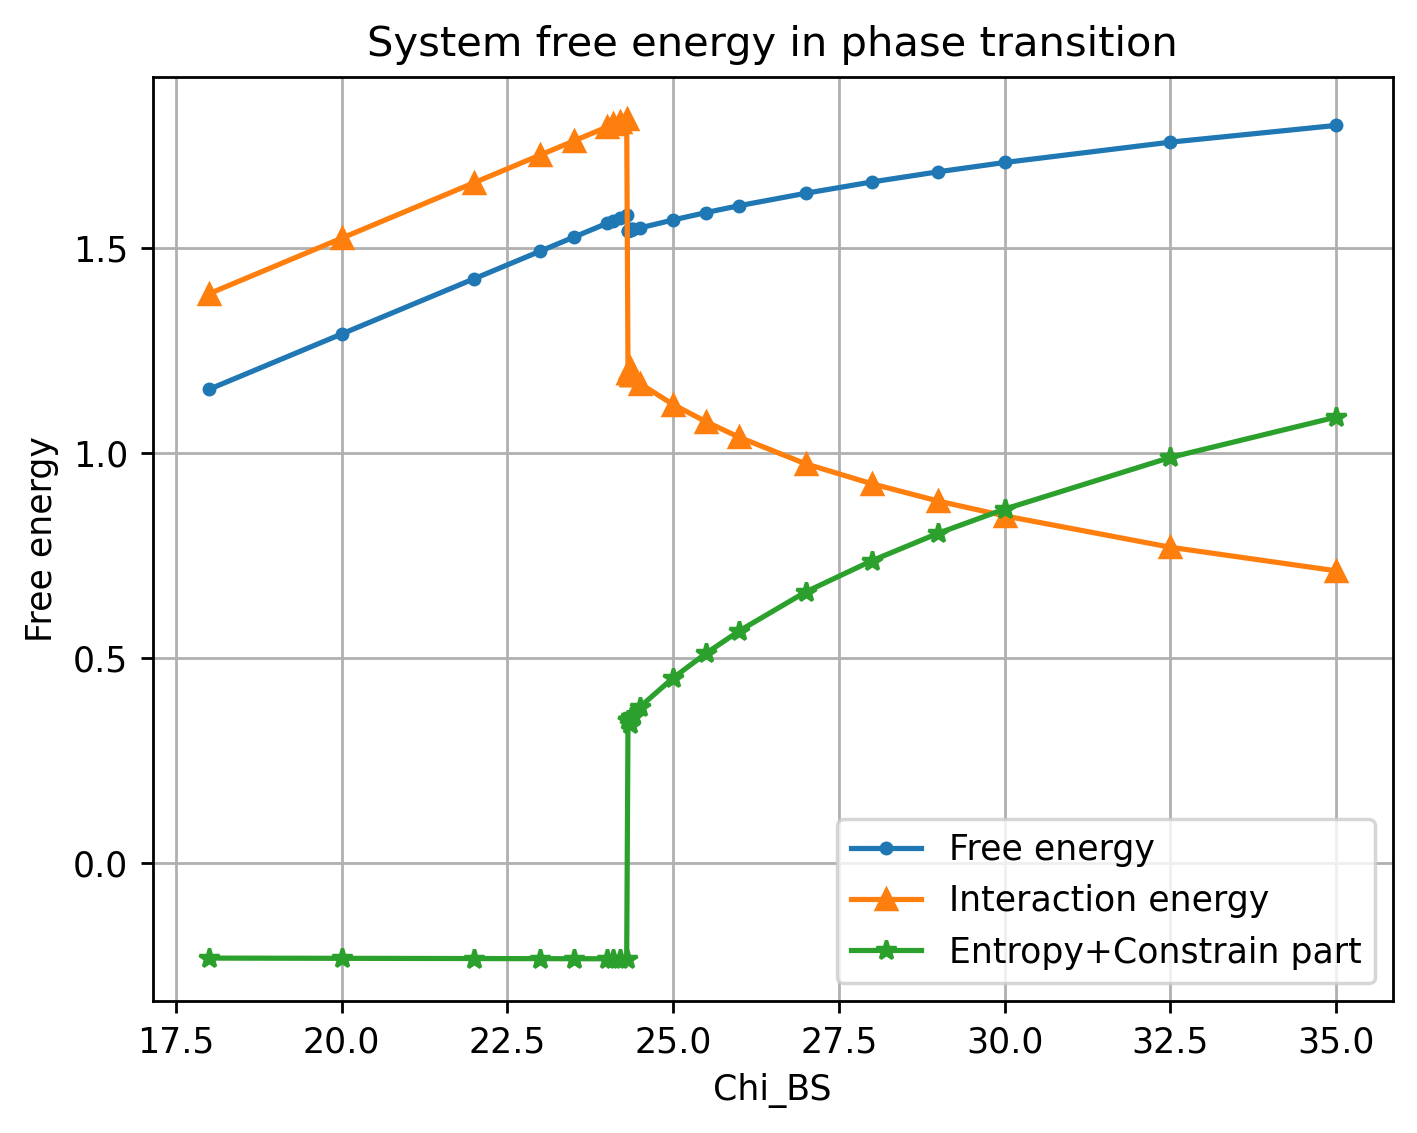

In [16]:
plt.figure(dpi=250)
final_energy[17, :] = np.nan
final_energy[14, :] = np.nan
final_energy[12, :] = np.nan
plt.plot(chi_bs_list, final_energy[:, 0],label="Free energy", marker='.')
plt.plot(chi_bs_list, final_energy[:, 1],label="Interaction energy", marker = '^')
plt.plot(chi_bs_list, final_energy[:, 2],label="Entropy+Constrain part", marker = '*')
plt.legend()
plt.grid()

plt.title("System free energy in phase transition")
plt.xlabel("Chi_BS")
plt.ylabel("Free energy")

18.0


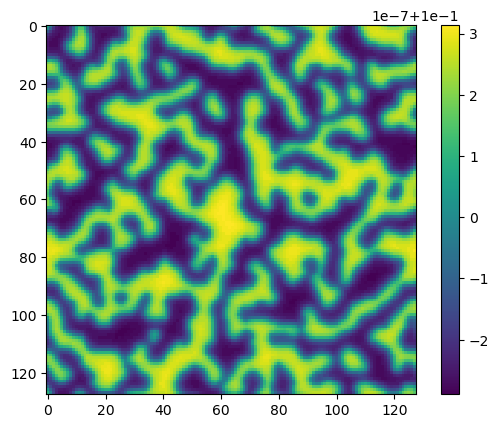

20.0


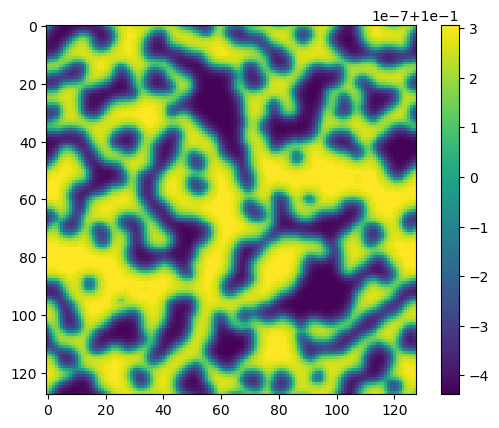

22.0


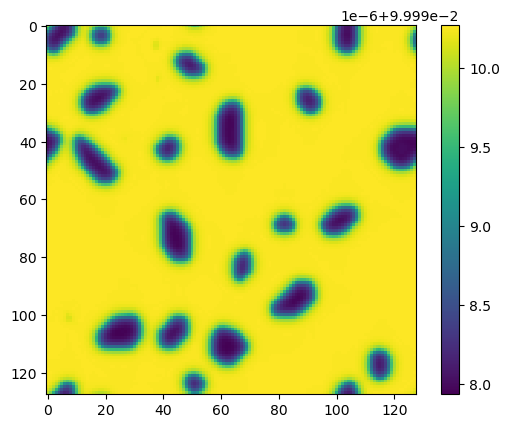

23.0


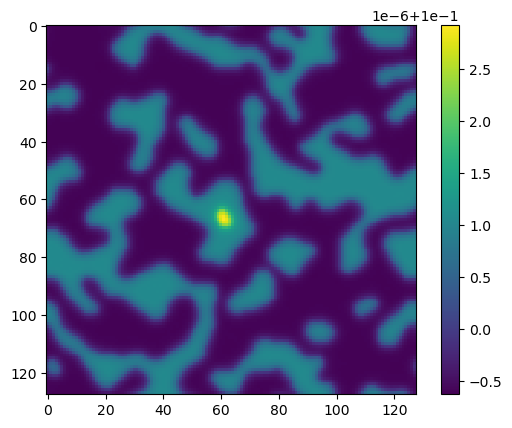

23.5


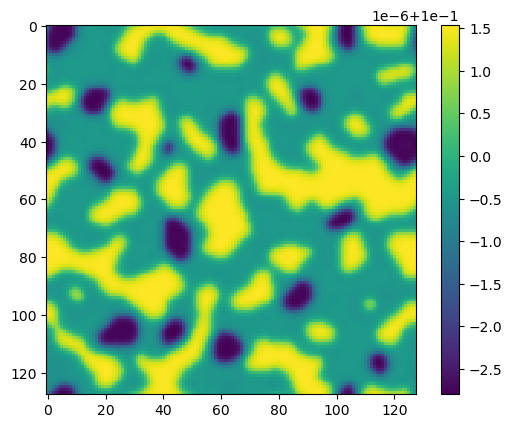

24.0


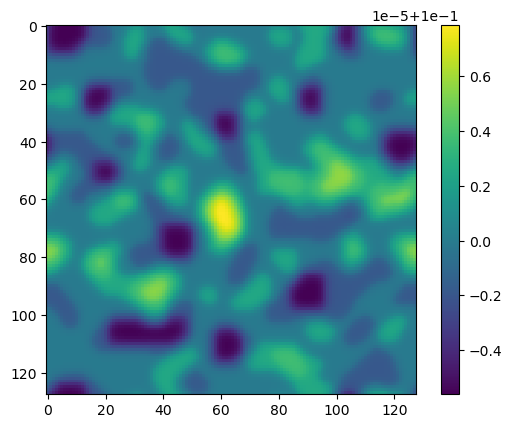

24.1


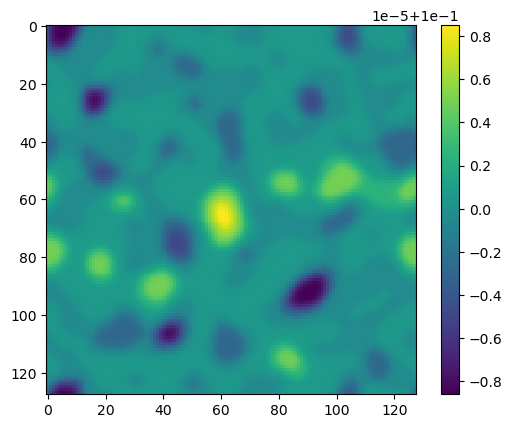

24.2


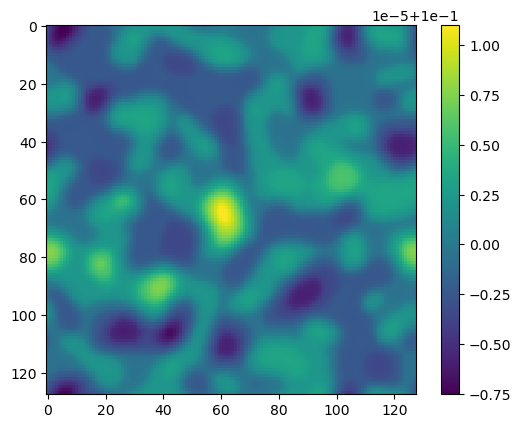

24.3


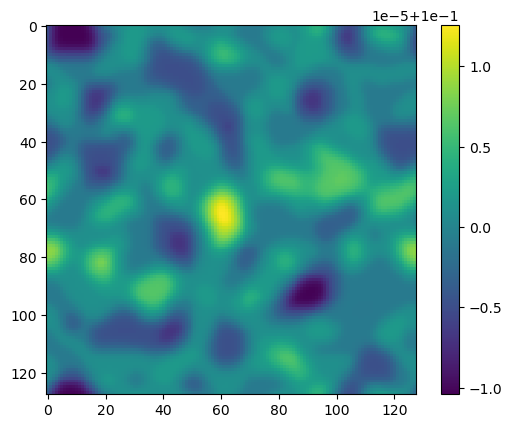

24.32


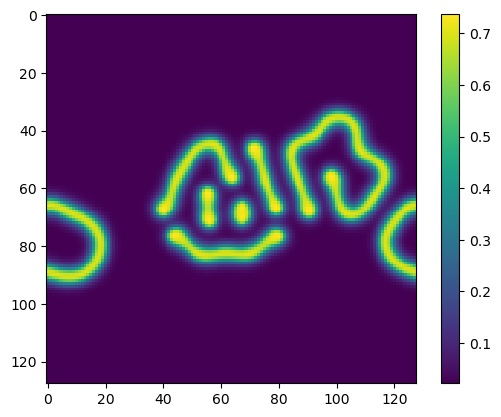

24.32


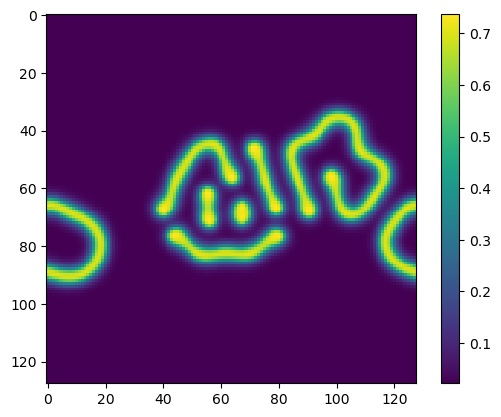

24.33


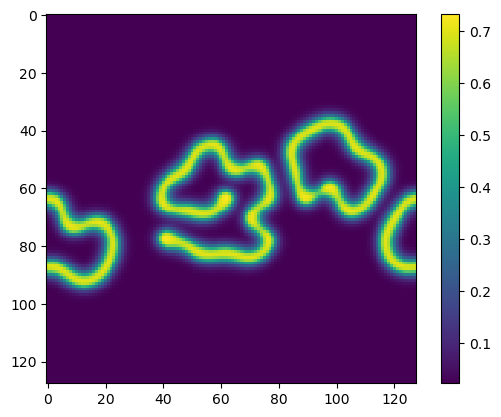

24.34


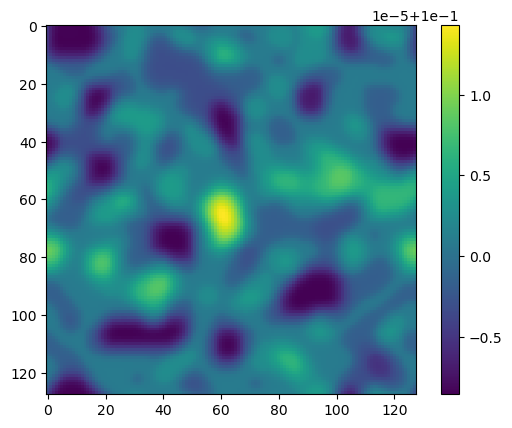

24.35


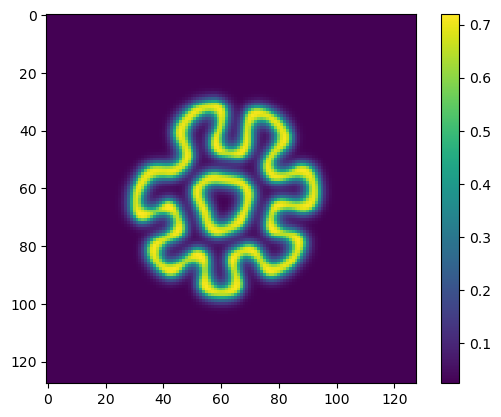

24.36


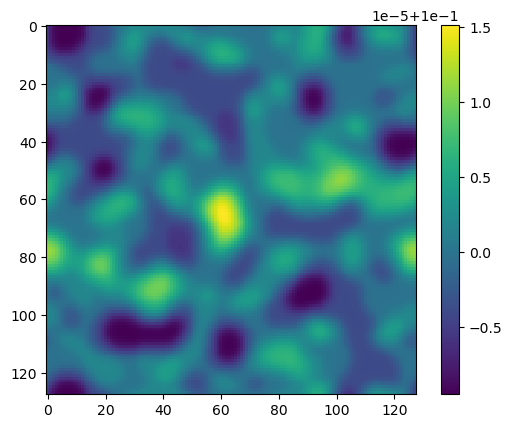

24.37


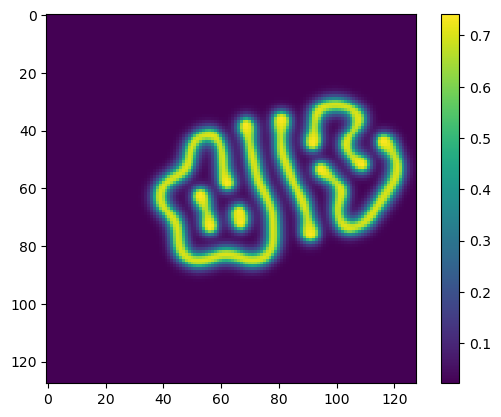

24.38


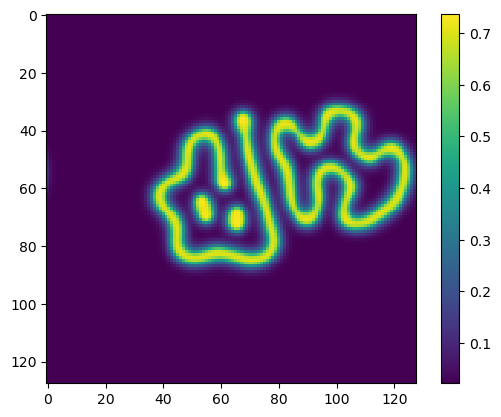

24.39


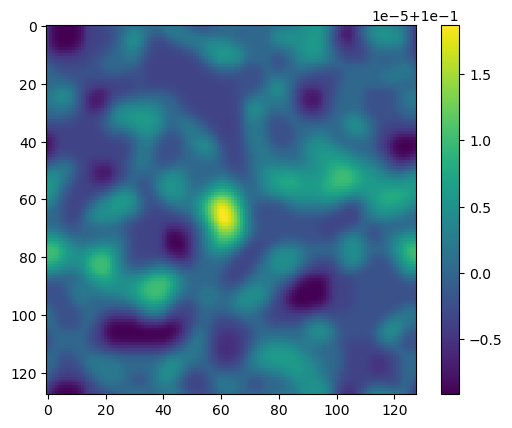

24.4


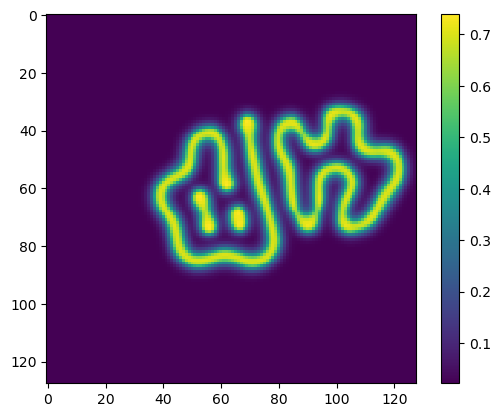

24.5


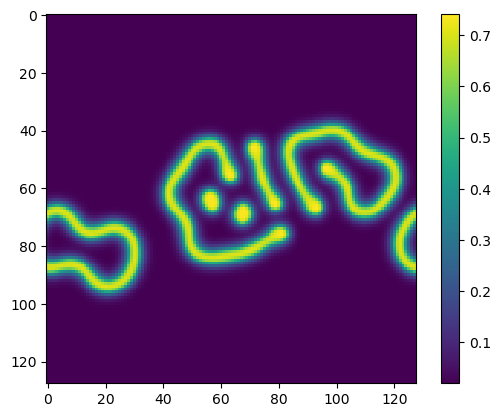

25.0


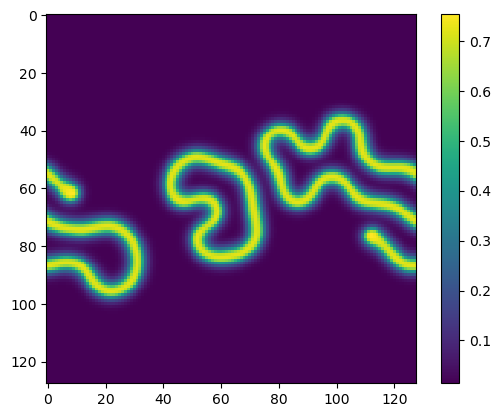

25.5


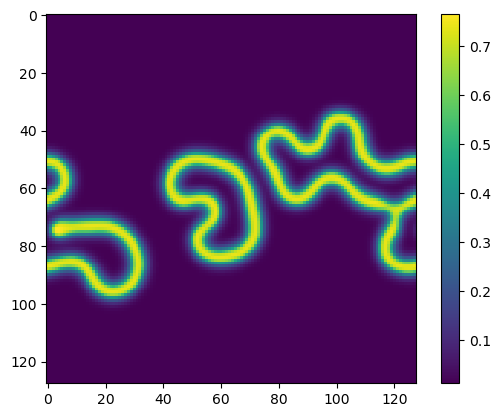

26.0


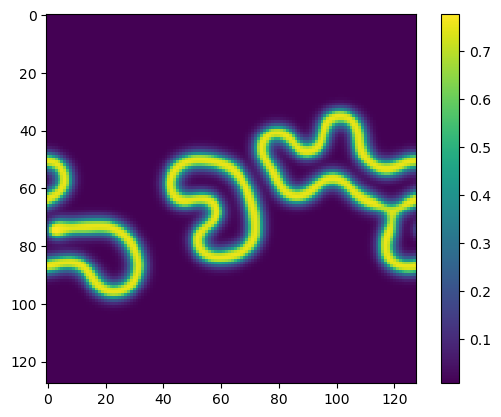

27.0


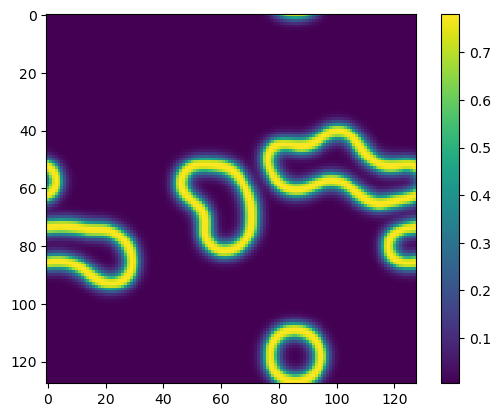

28.0


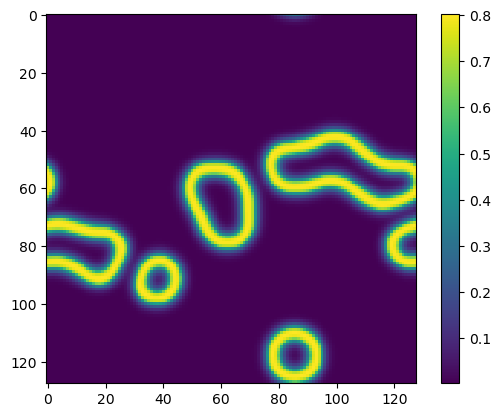

29.0


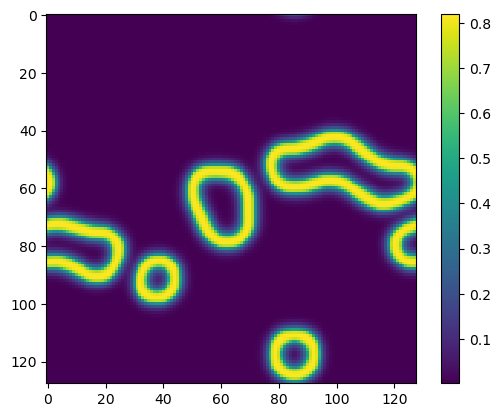

30.0


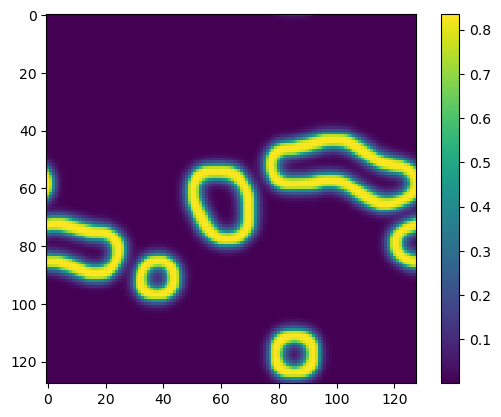

32.5


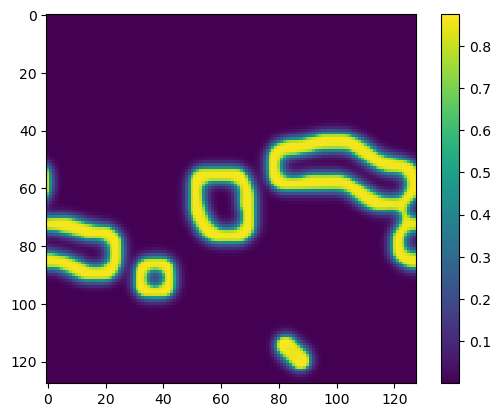

35.0


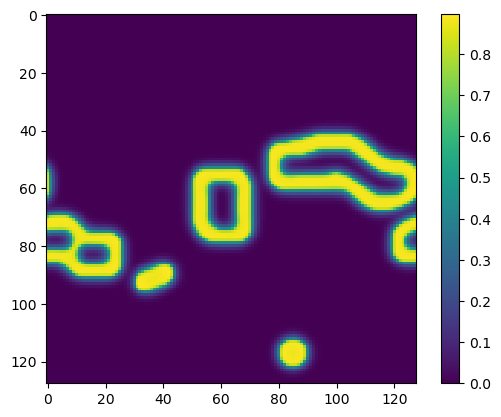

In [11]:
for i in range(len(chi_bs_list)):
    print(chi_bs_list[i])
    plt.imshow(np.sum(phi_list[i], axis = 0), cmap='viridis', interpolation='nearest', aspect=1)
    plt.colorbar()
    plt.show()
